<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 12 - Reinforcement Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Reinforcement Learning

Everything in the course so far learned from **labelled examples**: an input and the right answer. Many problems have no right answer to copy. A game is won or lost after hundreds of moves; a robot falls after a sequence of small mistakes; a recommender only learns whether you clicked what it showed you; a chatbot gets a thumbs up or down for a whole answer. **Reinforcement learning** (RL) learns to act from a scalar **reward**, by trial and error, and the agent's own actions decide which data it sees next.

In this lab we build the main ideas of RL from scratch, on small problems where every number can be checked: a bandit, a gridworld whose optimal policy we can compute exactly, the classic random walk and cliff walk, CartPole written from its physics equations, a tiny DQN, and a miniature of RLHF, the RL step used to tune chat models.

**Contents**

1. Bandits: the explore–exploit trade-off
2. A gridworld MDP from scratch
3. Policy evaluation: the Bellman expectation equation
4. Value iteration and policy iteration
5. The discount and the slip shape the optimal policy
6. Learning from experience: Monte Carlo vs TD(0)
7. SARSA vs Q-learning on the cliff
8. Policy gradients: REINFORCE with a baseline on CartPole
9. A tiny DQN: replay buffer and target network
10. RLHF in miniature: preferences, a reward model and a KL leash
11. Summary and exercises

This lab goes with the slides *Extra 12 · Reinforcement learning* and uses the same notation. It assumes the neural-network part of the course: MLPs, softmax and cross-entropy, gradient descent and the PyTorch training loop. No RL library is needed: every environment is a few lines of NumPy. The whole notebook runs on a CPU in about 1.5 minutes (with 4 CPU threads); a GPU would not help.

**Notation**

| Symbol | Meaning |
|---|---|
| $t$; $S_t$, $A_t$, $R_{t+1}$ | time step; state, action, and the reward that follows $A_t$ |
| $\mathcal S$, $\mathcal A$ | sets of states and actions |
| $P(s' \mid s, a)$ | transition probability; $r(s, a, s')$ the reward of a transition (in the gridworld it depends on $s'$ only) |
| $R(s, a) = \sum_{s'} P(s' \mid s, a)\, r(s, a, s')$ | expected immediate reward |
| $\gamma \in [0, 1)$ | discount factor |
| $G_t = \sum_{k \ge 0} \gamma^k R_{t+k+1}$ | return: the discounted sum of future rewards |
| $\pi(a \mid s)$ | policy: probability of action $a$ in state $s$ |
| $V^\pi(s)$, $Q^\pi(s, a)$ | value of a state, value of an action in a state, when following $\pi$ |
| $V^*$, $Q^*$, $\pi^*$ | optimal values and an optimal policy |
| $\alpha$; $\varepsilon$ | step size (learning rate); exploration rate of ε-greedy |
| $\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$ | TD error |
| $\mu_a$, $N_a$, $\hat\mu_a$ | bandit: mean reward of arm $a$, number of pulls, empirical mean |
| $\pi_\theta$; $A(s, a) = Q(s, a) - V(s)$ | policy with parameters $\theta$; advantage |
| $\pi_{\text{ref}}$, $\beta$, $\hat r$ | RLHF: reference policy, KL weight, learned reward model |

In [1]:
import time, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
np.random.seed(0); torch.manual_seed(0)
device = "cpu"          # tiny networks fed one step at a time: a GPU would only add overhead here
print("device:", device, "| torch", torch.__version__, "| numpy", np.__version__)
T_START = time.time()

device: cpu | torch 2.12.0+cu130 | numpy 2.3.3


## 1. Bandits: the explore–exploit trade-off

The simplest RL problem has a single state. A **multi-armed bandit** is a row of $K$ slot machines ("one-armed bandits"). Pulling arm $a$ pays a random reward with an unknown mean $\mu_a$, and the goal is to collect as much reward as possible in $T$ pulls. No states, no delays, and yet the central difficulty of RL is already here: to find the best arm you must try the others (**explore**), but every pull of a worse arm costs reward that you could have had by pulling the best one you know (**exploit**).

Our bandit has $K = 10$ Bernoulli arms: arm $a$ pays 1 with probability $\mu_a$ and 0 otherwise. The best arm is arm 7 with $\mu^* = 0.8$; the second best, arm 3, pays 0.7.

**Regret** measures the cost of learning: the reward lost against an oracle that always pulls the best arm,
$$
\text{Regret}(T) = T\mu^* - \sum_{t=1}^{T} \mu_{A_t} = \sum_{t=1}^{T} \Delta_{A_t}, \qquad \Delta_a = \mu^* - \mu_a .
$$
(This is the *pseudo-regret*: it uses the means, not the noisy rewards, so the curves are smooth.) Four strategies, all built on the empirical mean $\hat\mu_a$ = successes of $a$ / $N_a$:

- **greedy**: pull each arm once, then always the arm with the largest $\hat\mu_a$;
- **ε-greedy**: the same, but with probability $\varepsilon$ pull an arm at random;
- **UCB** (upper confidence bound): pull $\arg\max_a\ \hat\mu_a + c\sqrt{\ln t / N_a}$. The bonus is large for arms tried rarely: *optimism in the face of uncertainty*. UCB1 (Auer et al., 2002) uses $c = \sqrt 2$, which comes from Hoeffding's inequality and guarantees $O(\log T)$ regret;
- **Thompson sampling** (Thompson, 1933): keep a Beta posterior per arm, $\mu_a \sim \text{Beta}(1 + \text{successes}, 1 + \text{failures})$ (a uniform prior updated by Bayes' rule), draw one sample from each posterior and pull the arm with the largest sample. Each arm is pulled with exactly the probability that it is the best one, given the data so far.

Each strategy plays 400 independent runs of 5,000 pulls, vectorised over the runs.

In [2]:
MU = np.array([0.30, 0.55, 0.20, 0.70, 0.45, 0.60, 0.35, 0.80, 0.50, 0.25])   # success rate of each arm (unknown to the agent)
K, BEST = len(MU), int(MU.argmax())

def run_bandit(algo, runs=400, T=5000, eps=0.1, c=np.sqrt(2), seed=1):
    """Play `runs` independent copies of the 10-armed Bernoulli bandit for T steps, vectorised over the runs.
    algo: 'greedy', 'eps' (ε-greedy), 'ucb' (μ̂ + c·sqrt(ln t / N)) or 'thompson' (Beta posteriors).
    Returns the cumulative pseudo-regret (runs × T) and a mask 'the best arm was pulled' (runs × T)."""
    rng = np.random.default_rng(seed)
    N = np.zeros((runs, K)); S = np.zeros((runs, K))            # pulls and successes of every arm
    regret = np.zeros((runs, T)); best = np.zeros((runs, T), dtype=bool)
    rows = np.arange(runs)
    for t in range(T):
        mean = S / np.maximum(N, 1)                              # empirical means μ̂_a
        if algo == "thompson":
            score = rng.beta(S + 1, N - S + 1)                   # one sample from each posterior Beta(1 + S, 1 + N - S)
        else:
            score = mean + (c * np.sqrt(np.log(t + 1) / np.maximum(N, 1)) if algo == "ucb" else 0)
            score[N == 0] = np.inf                               # pull every arm once first
        a = np.argmax(score + 1e-9 * rng.random((runs, K)), axis=1)   # random tie-breaking
        if algo == "eps":
            explore = rng.random(runs) < eps
            a[explore] = rng.integers(0, K, explore.sum())
        r = (rng.random(runs) < MU[a]).astype(float)            # Bernoulli reward: 1 with probability μ_a
        N[rows, a] += 1; S[rows, a] += r
        regret[:, t] = MU[BEST] - MU[a]; best[:, t] = a == BEST
    return regret.cumsum(1), best

ALGOS = {"greedy": dict(algo="greedy"), "ε-greedy (ε = 0.1)": dict(algo="eps"),
         "UCB1 (c = √2)": dict(algo="ucb"), "UCB (c = 0.5)": dict(algo="ucb", c=0.5),
         "Thompson sampling": dict(algo="thompson")}
t0 = time.time()
results = {name: run_bandit(**kw) for name, kw in ALGOS.items()}
print(f"5 algorithms × 400 runs × 5000 steps in {time.time() - t0:.1f} s")
print(f"{'':20s} regret at t = 100   1000   5000   best arm in the last 500 steps")
for name, (reg, best) in results.items():
    print(f"{name:20s} {reg[:, 99].mean():12.1f} {reg[:, 999].mean():6.1f} {reg[:, -1].mean():6.1f} {100 * best[:, -500:].mean():12.1f} %")

5 algorithms × 400 runs × 5000 steps in 1.8 s
                     regret at t = 100   1000   5000   best arm in the last 500 steps
greedy                       11.6   64.9  297.3         62.5 %
ε-greedy (ε = 0.1)           14.0   66.5  214.0         90.0 %
UCB1 (c = √2)                26.0  151.1  323.1         87.2 %
UCB (c = 0.5)                16.5   40.6   59.8         98.1 %
Thompson sampling            18.4   46.2   61.6         99.0 %


ε-greedy regret per step over t = 3000..5000: 0.0346   (expected ≈ ε·(μ* − mean μ) = 0.0330)
greedy: 38 % of the runs are stuck on a worse arm at the end
Thompson: regret added per doubling of t: ['8.4', '7.2', '6.7', '6.4'] (roughly constant: regret ∝ log t)


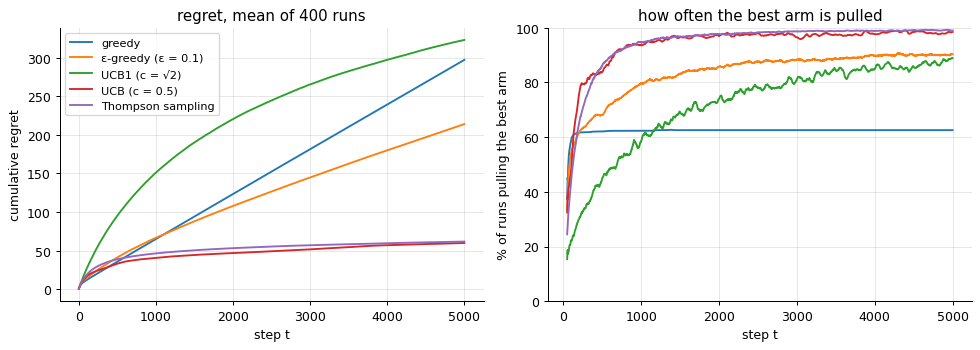

In [3]:
reg_eps = results["ε-greedy (ε = 0.1)"][0].mean(0)
slope = (reg_eps[4999] - reg_eps[2999]) / 2000
print(f"ε-greedy regret per step over t = 3000..5000: {slope:.4f}   (expected ≈ ε·(μ* − mean μ) = {0.1 * (MU.max() - MU.mean()):.4f})")
stuck = (results["greedy"][1][:, -500:].mean(1) < 0.5).mean()
print(f"greedy: {100 * stuck:.0f} % of the runs are stuck on a worse arm at the end")
reg_ts = results["Thompson sampling"][0].mean(0)
print("Thompson: regret added per doubling of t:",
      [f"{reg_ts[2 * t - 1] - reg_ts[t - 1]:.1f}" for t in (312, 625, 1250, 2500)], "(roughly constant: regret ∝ log t)")
assert abs(slope - 0.1 * (MU.max() - MU.mean())) < 0.006

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tt = np.arange(1, 5001)
for name, (reg, best) in results.items():
    axes[0].plot(tt, reg.mean(0), label=name)
    axes[1].plot(tt[49:], np.convolve(best.mean(0), np.ones(50) / 50, mode="valid") * 100, label=name)   # moving average of 50 steps
axes[0].set_xlabel("step t"); axes[0].set_ylabel("cumulative regret"); axes[0].set_title("regret, mean of 400 runs")
axes[0].legend(fontsize=9)
axes[1].set_xlabel("step t"); axes[1].set_ylabel("% of runs pulling the best arm"); axes[1].set_ylim(0, 100)
axes[1].set_title("how often the best arm is pulled")
plt.tight_layout(); plt.show()

**What just happened?**

- **Greedy** commits after one pull per arm. If the best arm happens to pay 0 on that first pull, its estimate is 0 and it may never be pulled again: 38 % of the runs end stuck on a worse arm, and the regret grows linearly (297 after 5,000 pulls).
- **ε-greedy** finds the best arm (it pulls it in 90 % of the steps at the end) but never stops exploring: 10 % of the pulls are random and cost on average $\mu^* - \bar\mu = 0.33$ each. Predicted regret per step $\varepsilon \cdot 0.33 = 0.033$; measured 0.035. Linear regret again (214).
- **UCB1** with the textbook constant $c = \sqrt 2$ explores too much for this horizon (323): its bonus $\sqrt{2\ln t/N_a}$ is large compared with the gap of 0.1 between the two best arms. With $c = 0.5$ the regret drops to 60. The guarantee is about the growth rate, not the constant.
- **Thompson sampling** reaches 62 without any tuning, and the regret it adds per doubling of $t$ is almost constant (8.4, 7.2, 6.7, 6.4): its regret grows like $\log t$. Lai and Robbins (1985) proved that no strategy can do better than logarithmic regret: every worse arm needs about $\log T$ pulls to be ruled out with confidence.

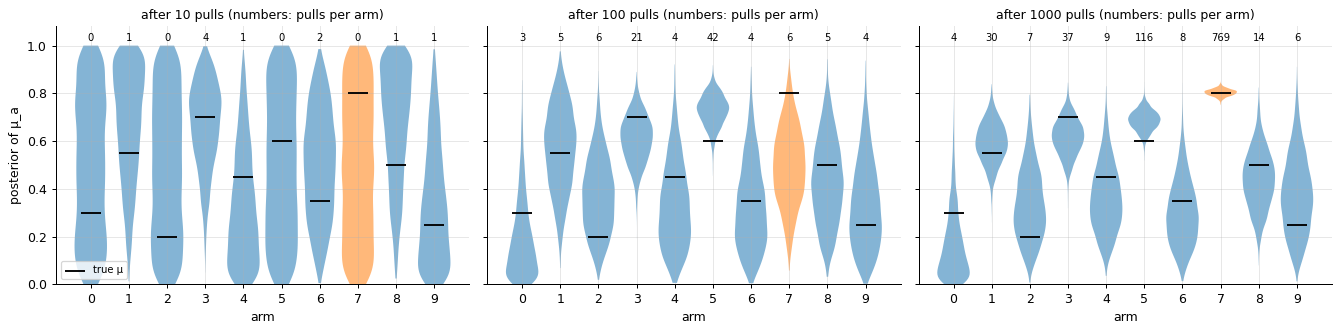

pulls after 1000 steps: [  4  30   7  37   9 116   8 769  14   6]   (best arm = arm 7 )


In [4]:
def thompson_snapshots(T, checkpoints, seed=3):
    """One run of Thompson sampling; returns (N, S) at each checkpoint."""
    rng = np.random.default_rng(seed); N = np.zeros(K); S = np.zeros(K); snaps = {}
    for t in range(1, T + 1):
        a = int(np.argmax(rng.beta(S + 1, N - S + 1)))
        r = float(rng.random() < MU[a]); N[a] += 1; S[a] += r
        if t in checkpoints: snaps[t] = (N.copy(), S.copy())
    return snaps

snaps = thompson_snapshots(1000, {10, 100, 1000})
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
rng_v = np.random.default_rng(0)
for ax, t in zip(axes, sorted(snaps)):
    N, S = snaps[t]
    parts = ax.violinplot([rng_v.beta(S[a] + 1, N[a] - S[a] + 1, 4000) for a in range(K)], positions=range(K),
                          showextrema=False, widths=0.85)
    for a, body in enumerate(parts["bodies"]):
        body.set_facecolor("tab:orange" if a == BEST else "tab:blue"); body.set_alpha(0.55)
    ax.scatter(range(K), MU, color="k", marker="_", s=250, zorder=3, label="true μ")
    for a in range(K):
        ax.text(a, 1.02, f"{int(N[a])}", ha="center", fontsize=8)
    ax.set_xticks(range(K)); ax.set_xlabel("arm"); ax.set_ylim(0, 1.08)
    ax.set_title(f"after {t} pulls (numbers: pulls per arm)", fontsize=10)
axes[0].set_ylabel("posterior of μ_a"); axes[0].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()
print("pulls after 1000 steps:", snaps[1000][0].astype(int), "  (best arm = arm", BEST, ")")

**Things to notice.** After 10 pulls the posteriors are wide and overlap, so the Thompson samples are almost random: the algorithm explores. After 100 pulls the clearly bad arms have posteriors far below 0.8 and their samples rarely win. After 1,000 pulls the best arm has 769 pulls and a narrow posterior. The remaining exploration went where it was still plausible that an arm could be the best: 116 pulls for the 0.6 arm and 37 for the 0.7 arm, only 4 to 14 for the others. The exploration fades by itself as the posteriors shrink, which is exactly what ε-greedy lacks.

Bandits are used in practice for A/B tests that adapt while they run, news and ad recommendation (contextual bandits, where the arm values depend on features of the user), and dynamic pricing. They are RL with one state: the action changes the reward, but not the future situation.

## 2. A gridworld MDP from scratch

A **Markov decision process** (MDP) adds states. At each step $t$ the agent observes a state $S_t$, picks an action $A_t$, and the environment returns a reward $R_{t+1}$ and a next state $S_{t+1}$ drawn from $P(s' \mid s, a)$. *Markov* means that $(S_t, A_t)$ is all the environment needs to decide what happens next: the past adds nothing once you know the present state.

Our MDP is a 4 × 5 grid:

```
. . . . .        S  start
. # A # B        #  wall
S . . . .        A  exit, reward +1  (the episode ends)
C C C C C        B  exit, reward +10 (the episode ends)
                 C  cliff, reward −10 (the episode ends)
```

- 4 actions: up, right, down, left. The floor is **slippery**: the intended move happens with probability 0.8, and with probability 0.1 each the agent moves in one of the two perpendicular directions. Moving into a wall or the border leaves it in place.
- Reward: the exit's value when entering A, B or C; 0 for every other move.
- Discount $\gamma = 0.9$: a reward $k$ steps in the future is worth $\gamma^k$ times the same reward now.

The near exit is worth little, the far one a lot, and the short way to both runs along the cliff. Which way is best depends on $\gamma$ and on the slip (sections 4 and 5).

The agent wants to maximise the expected **return**, the discounted sum of future rewards:
$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots = \sum_{k \ge 0} \gamma^k R_{t+k+1} = R_{t+1} + \gamma\, G_{t+1}.
$$
With $\gamma < 1$ and bounded rewards the sum is finite, and the recursion on the right is behind every algorithm of this lab.

We store the model as a transition tensor $P[s, a, s']$ and the expected reward $R[s, a] = \sum_{s'} P(s' \mid s, a)\, r(s')$. The planning methods of sections 3 to 5 read them. The learning methods of sections 6 to 9 only get samples from a black box `env.step(a)`, like an agent in the real world.

In [5]:
LAYOUT = [".....",
          ".#A#B",
          "S....",
          "CCCCC"]
EXIT_REWARD = {"A": 1.0, "B": 10.0, "C": -10.0}      # entering A, B or the cliff C ends the episode
N_ROWS, N_COLS = len(LAYOUT), len(LAYOUT[0])
CELLS = [(r, c) for r in range(N_ROWS) for c in range(N_COLS) if LAYOUT[r][c] != "#"]
STATE = {rc: s for s, rc in enumerate(CELLS)}           # (row, col) -> state index
nS, nA = len(CELLS), 4
ACTIONS, ARROWS = ["up", "right", "down", "left"], "↑→↓←"
MOVES = [(-1, 0), (0, 1), (1, 0), (0, -1)]
TERMINAL = np.array([LAYOUT[r][c] in EXIT_REWARD for r, c in CELLS])
START = STATE[(2, 0)]

def make_mdp(slip=0.2, living=0.0):
    """P[s, a, s'] and the expected reward R[s, a] = Σ_s' P(s'|s, a) r(s').
    The intended move happens with probability 1 - slip, each perpendicular move with slip / 2.
    Walls and borders leave the agent in place. r(s') = exit reward if s' is terminal, else `living`.
    Terminal states are absorbing with reward 0."""
    P = np.zeros((nS, nA, nS)); R = np.zeros((nS, nA))
    for s, (r, c) in enumerate(CELLS):
        if TERMINAL[s]:
            P[s, :, s] = 1.0
            continue
        for a in range(nA):
            for b, p in [(a, 1 - slip), ((a + 1) % 4, slip / 2), ((a + 3) % 4, slip / 2)]:
                rr, cc = r + MOVES[b][0], c + MOVES[b][1]
                if not (0 <= rr < N_ROWS and 0 <= cc < N_COLS) or LAYOUT[rr][cc] == "#":
                    rr, cc = r, c                                   # bump: stay in place
                P[s, a, STATE[(rr, cc)]] += p
                R[s, a] += p * EXIT_REWARD.get(LAYOUT[rr][cc], living)
    return P, R

GAMMA, SLIP = 0.9, 0.2
P, R = make_mdp(SLIP)
R_NEXT = np.array([EXIT_REWARD.get(LAYOUT[r][c], 0.0) for r, c in CELLS])   # reward for entering each cell
s_B = STATE[(2, 4)]
print(f"{nS} states ({TERMINAL.sum()} terminal), {nA} actions, P has shape {P.shape}")
print("every P[s, a, :] sums to 1:", np.allclose(P.sum(-1), 1))
print("from the cell below B, action up:", {CELLS[s2]: round(float(p), 2) for s2, p in enumerate(P[s_B, 0]) if p > 0},
      " expected reward R =", R[s_B, 0], "(= 0.8 · 10)")

18 states (7 terminal), 4 actions, P has shape (18, 4, 18)
every P[s, a, :] sums to 1: True
from the cell below B, action up: {(1, 4): 0.8, (2, 3): 0.1, (2, 4): 0.1}  expected reward R = 8.0 (= 0.8 · 10)


In [6]:
class GridEnv:
    """The same MDP as a black box: reset() -> s, step(a) -> (s', r, done). The agent never sees P."""
    def __init__(self, P, r_next, seed=0):
        self.cum, self.r_next, self.rng = P.cumsum(-1), r_next, np.random.default_rng(seed)
    def reset(self):
        self.s = START
        return self.s
    def step(self, a):
        s2 = min(int(np.searchsorted(self.cum[self.s, a], self.rng.random(), side="right")), nS - 1)
        self.s = s2
        return s2, self.r_next[s2], bool(TERMINAL[s2])

def rollout(env, policy, rng, max_steps=200):
    """One episode; policy is an nS × nA matrix of probabilities. Returns the list of (s, a, r)."""
    s, traj = env.reset(), []
    for _ in range(max_steps):
        a = int(rng.choice(nA, p=policy[s]))
        s2, r, done = env.step(a)
        traj.append((s, a, r)); s = s2
        if done: break
    return traj, s

def discounted_return(rewards, gamma=GAMMA):
    return sum(gamma ** k * r for k, r in enumerate(rewards))

PI_RANDOM = np.full((nS, nA), 0.25)
env, rng = GridEnv(P, R_NEXT, seed=0), np.random.default_rng(106)   # different seeds: independent random streams
traj, last = rollout(env, PI_RANDOM, rng)
print("one episode of the random policy:")
print("  " + "  ".join(f"{CELLS[s]}{ARROWS[a]}" for s, a, _ in traj[:12]), "..." if len(traj) > 12 else "", "->", CELLS[last])
print(f"  {len(traj)} steps, non-zero rewards {[float(r) for *_, r in traj if r != 0]}, return G_0 = {discounted_return([r for *_, r in traj]):.3f}")
returns = np.array([discounted_return([r for *_, r in rollout(env, PI_RANDOM, rng)[0]]) for _ in range(5000)])
print(f"Monte Carlo estimate of V_random(S) from 5000 episodes: {returns.mean():.3f} ± {returns.std() / np.sqrt(5000):.3f} (standard error)")

one episode of the random policy:
  (2, 0)←  (2, 0)↑  (1, 0)↑  (0, 0)→  (0, 0)←  (0, 0)↑  (0, 1)→  (0, 2)↑  (0, 2)→  (0, 3)↑  (0, 4)↓  -> (1, 4)
  11 steps, non-zero rewards [10.0], return G_0 = 3.487


Monte Carlo estimate of V_random(S) from 5000 episodes: -5.852 ± 0.057 (standard error)


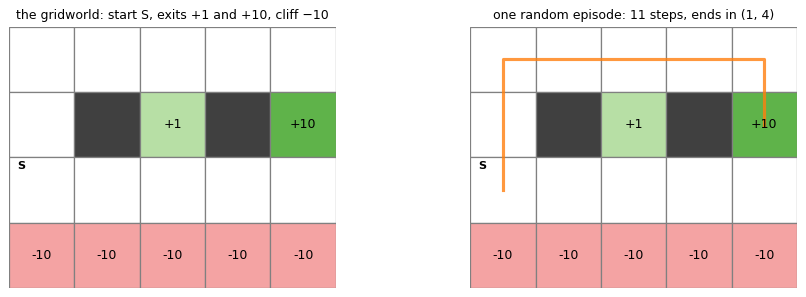

In [7]:
EXIT_COLOR = {"A": "#b7dfa5", "B": "#5fb34a", "C": "#f4a3a3"}

def draw_grid(ax, V=None, policy=None, path=None, title="", vmax=10, fmt="{:.2f}"):
    """Draw the gridworld: walls, exits, optional values V (heat map + numbers), greedy arrows, a path of cells."""
    for r in range(N_ROWS):
        for c in range(N_COLS):
            ch = LAYOUT[r][c]
            color = "#404040" if ch == "#" else EXIT_COLOR.get(ch, "white")
            if V is not None and ch in ".S":
                color = plt.cm.Blues(0.08 + 0.7 * max(0, V[STATE[(r, c)]]) / vmax) if V[STATE[(r, c)]] >= 0 \
                        else plt.cm.Reds(0.1 + 0.5 * min(1, -V[STATE[(r, c)]] / vmax))
            ax.add_patch(plt.Rectangle((c, -r - 1), 1, 1, facecolor=color, edgecolor="gray"))
            if ch in EXIT_REWARD:
                ax.text(c + 0.5, -r - 0.5, f"{EXIT_REWARD[ch]:+g}", ha="center", va="center", fontsize=10)
            elif ch != "#":
                s = STATE[(r, c)]
                if V is not None:
                    ax.text(c + 0.5, -r - 0.72, fmt.format(V[s]), ha="center", va="center", fontsize=9)
                if policy is not None and policy[s] >= 0:                  # -1 = no arrow (all actions tie)
                    dr, dc = MOVES[policy[s]]
                    ax.annotate("", xy=(c + 0.5 + 0.28 * dc, -r - 0.38 - 0.28 * dr), xytext=(c + 0.5, -r - 0.38),
                                arrowprops=dict(arrowstyle="->", lw=1.6, color="k"))
                if ch == "S":
                    ax.text(c + 0.12, -r - 0.18, "S", fontsize=9, fontweight="bold")
    if path is not None:
        xy = np.array([(CELLS[s][1] + 0.5, -CELLS[s][0] - 0.5) for s in path])
        ax.plot(xy[:, 0], xy[:, 1], color="tab:orange", lw=2.5, alpha=0.8)
    ax.set_xlim(0, N_COLS); ax.set_ylim(-N_ROWS, 0); ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
draw_grid(axes[0], title="the gridworld: start S, exits +1 and +10, cliff −10")
draw_grid(axes[1], path=[s for s, _, _ in traj] + [last], title=f"one random episode: {len(traj)} steps, ends in {CELLS[last]}")
plt.tight_layout(); plt.show()

**What just happened?** 18 cells are states (the 2 walls are not), 7 of them terminal. Every row $P[s, a, :]$ is a probability distribution. From the cell below B, "up" enters B with probability 0.8, so its expected immediate reward is $0.8 \cdot 10 = 8$.

The random policy (each action with probability 1/4) wandered for 11 moves and happened to reach B: the reward 10 arrived on the 11th move, so the return is $0.9^{10} \cdot 10 = 3.487$. That episode was lucky. Averaged over 5,000 episodes the return from S is $-5.85 \pm 0.06$: starting next to the cliff with random moves, falling in is the most likely outcome. That average is a **Monte Carlo** estimate of the value $V^\pi(S)$, the expected return of the policy from S. Section 3 computes it exactly.

## 3. Policy evaluation: the Bellman expectation equation

A **policy** $\pi(a \mid s)$ gives the probability of each action in each state. Its **value functions** are expected returns:
$$
V^\pi(s) = \mathbb E_\pi[\,G_t \mid S_t = s\,], \qquad Q^\pi(s, a) = \mathbb E_\pi[\,G_t \mid S_t = s, A_t = a\,], \qquad V^\pi(s) = \sum_a \pi(a \mid s)\, Q^\pi(s, a).
$$

**Derivation of the Bellman expectation equation.** Write $G_t = R_{t+1} + \gamma G_{t+1}$, then condition on the first action $a$ and the next state $s'$:
$$
\begin{aligned}
V^\pi(s) &= \mathbb E_\pi[\,R_{t+1} + \gamma\, G_{t+1} \mid S_t = s\,] \\
&= \sum_a \pi(a \mid s) \sum_{s'} P(s' \mid s, a)\,\Big(r(s') + \gamma\, \mathbb E_\pi[\,G_{t+1} \mid S_{t+1} = s'\,]\Big) \\
&= \sum_a \pi(a \mid s) \sum_{s'} P(s' \mid s, a)\,\big(r(s') + \gamma\, V^\pi(s')\big).
\end{aligned}
$$
The second line uses the Markov property: once we know $S_{t+1} = s'$, the future does not depend on how we got there. In words: **the value of a state is the expected immediate reward plus the discounted value of where you land.**

With the policy's averages $P_\pi[s, s'] = \sum_a \pi(a \mid s) P(s' \mid s, a)$ and $r_\pi[s] = \sum_a \pi(a \mid s) R[s, a]$ this is a linear system:
$$
V^\pi = r_\pi + \gamma P_\pi V^\pi \quad\Longrightarrow\quad V^\pi = (\mathbf I - \gamma P_\pi)^{-1}\, r_\pi .
$$
$\mathbf I - \gamma P_\pi$ is invertible: the eigenvalues of the stochastic matrix $P_\pi$ have modulus at most 1, so those of $\gamma P_\pi$ are at most $\gamma < 1$.

Two ways to compute it: solve the system, or iterate $V_{k+1} = r_\pi + \gamma P_\pi V_k$ from $V_0 = 0$ (**iterative policy evaluation**). Each sweep shrinks the error by at least a factor $\gamma$, because each row of $P_\pi$ is an average and an average is never larger than the largest value:
$$
\|V_{k+1} - V^\pi\|_\infty = \gamma\,\|P_\pi (V_k - V^\pi)\|_\infty \le \gamma\,\|V_k - V^\pi\|_\infty .
$$
For millions of states the iteration, or a sampled version of it (section 6), is the only option.

iterative evaluation: 116 sweeps, max |difference with the exact solve| = 4.7e-10
V_random(S) exact = -5.911   Monte Carlo above: -5.852 ± 0.057
Bellman expectation equation at cell (0, 2): V = 1.1208, right-hand side = 1.1208


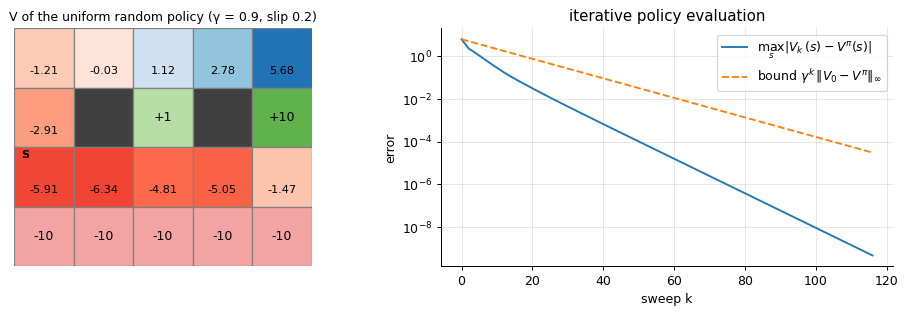

In [8]:
def policy_matrices(pi, P=P, R=R):
    """P_π[s, s'] = Σ_a π(a|s) P(s'|s, a) and r_π[s] = Σ_a π(a|s) R[s, a]."""
    return np.einsum("sa,sat->st", pi, P), (pi * R).sum(1)

def evaluate_exact(pi, gamma=GAMMA, P=P, R=R):
    """Solve the linear system V = r_π + γ P_π V."""
    P_pi, r_pi = policy_matrices(pi, P, R)
    return np.linalg.solve(np.eye(nS) - gamma * P_pi, r_pi)

def evaluate_iterative(pi, gamma=GAMMA, P=P, R=R, tol=1e-10):
    """Sweep V <- r_π + γ P_π V until the largest change is below tol. Returns V and the list of all sweeps."""
    P_pi, r_pi = policy_matrices(pi, P, R)
    V, hist = np.zeros(nS), [np.zeros(nS)]
    while True:
        V_new = r_pi + gamma * P_pi @ V
        hist.append(V_new)
        if np.abs(V_new - V).max() < tol: return V_new, hist
        V = V_new

V_rand = evaluate_exact(PI_RANDOM)
V_rand_it, hist_rand = evaluate_iterative(PI_RANDOM)
print(f"iterative evaluation: {len(hist_rand) - 1} sweeps, max |difference with the exact solve| = {np.abs(V_rand_it - V_rand).max():.1e}")
print(f"V_random(S) exact = {V_rand[START]:.3f}   Monte Carlo above: {returns.mean():.3f} ± {returns.std() / np.sqrt(5000):.3f}")
s0 = STATE[(0, 2)]
check = sum(PI_RANDOM[s0, a] * sum(P[s0, a, s2] * (R_NEXT[s2] + GAMMA * V_rand[s2]) for s2 in range(nS)) for a in range(nA))
print(f"Bellman expectation equation at cell (0, 2): V = {V_rand[s0]:.4f}, right-hand side = {check:.4f}")
assert np.allclose(V_rand_it, V_rand, atol=1e-8)
assert abs(returns.mean() - V_rand[START]) < 3 * returns.std() / np.sqrt(5000)
assert np.isclose(check, V_rand[s0])

err = [np.abs(h - V_rand).max() for h in hist_rand]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
draw_grid(axes[0], V=V_rand, vmax=6, title="V of the uniform random policy (γ = 0.9, slip 0.2)")
axes[1].semilogy(err, label=r"$\max_s |V_k(s) - V^\pi(s)|$")
axes[1].semilogy(err[0] * GAMMA ** np.arange(len(err)), "--", label=r"bound $\gamma^k \, \|V_0 - V^\pi\|_\infty$")
axes[1].set_xlabel("sweep k"); axes[1].set_ylabel("error"); axes[1].legend(); axes[1].set_title("iterative policy evaluation")
plt.tight_layout(); plt.show()

**What just happened?** The exact solve gives $V^{\text{random}}(S) = -5.911$, and the Monte Carlo average of section 2, $-5.85 \pm 0.06$, agrees within one standard error. Iterative evaluation reaches the same values (to $5 \cdot 10^{-10}$) after 116 sweeps, always below the $\gamma^k$ bound. The Bellman equation holds at every cell; at cell (0, 2), above the +1 exit, both sides are 1.1208.

The heat map shows how costly random moves are: every floor cell of the row next to the cliff is negative, and only the cells around the exits are clearly positive. Evaluating a policy is the first half of improving it.

## 4. Value iteration and policy iteration

The best possible values, $V^*(s) = \max_\pi V^\pi(s)$ and $Q^*(s, a) = \max_\pi Q^\pi(s, a)$, satisfy the **Bellman optimality equation**: the best value is that of the best action, its expected reward plus the discounted best value of where you land.
$$
V^*(s) = \max_a \sum_{s'} P(s' \mid s, a)\,\big(r(s') + \gamma\, V^*(s')\big) = \max_a Q^*(s, a), \qquad
Q^*(s, a) = R(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, \max_{a'} Q^*(s', a').
$$
Once $Q^*$ is known, acting is easy: $\pi^*(s) = \arg\max_a Q^*(s, a)$ is an optimal policy, deterministic and optimal from every start state at once. The max makes the equation non-linear, so instead of solving it we iterate.

**Value iteration** turns the equation into an update: $V_{k+1}(s) = \max_a \big[R(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V_k(s')\big]$. Call this map $\mathcal T$. It is a **γ-contraction** in the max norm, in one line:
$$
|\max_a f(a) - \max_a g(a)| \le \max_a |f(a) - g(a)| \;\Longrightarrow\; \|\mathcal T V - \mathcal T U\|_\infty \le \gamma \max_{s, a} \sum_{s'} P(s' \mid s, a)\, |V(s') - U(s')| \le \gamma\, \|V - U\|_\infty .
$$
So $\mathcal T$ has a unique fixed point, $V^*$ (Banach's fixed-point theorem), and from any start $\|V_k - V^*\|_\infty \le \gamma^k \|V_0 - V^*\|_\infty$.

**Policy iteration** alternates two steps: *evaluate* the current policy exactly (section 3), then *improve* it greedily, $\pi'(s) = \arg\max_a Q^\pi(s, a)$. The **policy improvement theorem** says that $V^{\pi'}(s) \ge V^\pi(s)$ in every state: acting greedily for one step and then following $\pi$ is at least as good as following $\pi$, and repeating the argument at every step shows it for following $\pi'$ forever. A finite MDP has finitely many deterministic policies, so policy iteration must stop, and it stops at an optimal policy, usually after very few improvements.

In [9]:
def value_iteration(P=P, R=R, gamma=GAMMA, tol=1e-10):
    """V <- max_a [R + γ P V] until convergence. Returns V*, Q* and the list of all sweeps V_0, V_1, ..."""
    V, hist = np.zeros(nS), [np.zeros(nS)]
    while True:
        Q = R + gamma * P @ V                  # Q[s, a] = R[s, a] + γ Σ_s' P(s'|s, a) V(s')
        V_new = Q.max(1)
        hist.append(V_new)
        if np.abs(V_new - V).max() < tol: return V_new, R + gamma * P @ V_new, hist
        V = V_new

def one_hot(pi_det):
    return np.eye(nA)[pi_det]

def policy_iteration(P=P, R=R, gamma=GAMMA):
    """Evaluate exactly, improve greedily, repeat until the policy is stable. Starts from 'always up'."""
    pi, values = np.zeros(nS, dtype=int), []
    while True:
        V = evaluate_exact(one_hot(pi), gamma, P, R); values.append(V[START])
        Q = R + gamma * P @ V
        new = np.where(np.isclose(Q[np.arange(nS), pi], Q.max(1)), pi, Q.argmax(1))   # keep the old action on ties
        if np.array_equal(new, pi): return pi, V, values
        pi = new

V_star, Q_star, hist_vi = value_iteration()
pi_star = Q_star.argmax(1)
pi_pi, V_pi, pi_values = policy_iteration()
resid = np.abs(V_star - (R + GAMMA * P @ V_star).max(1)).max()
dec = ~TERMINAL
print(f"value iteration : {len(hist_vi) - 1} sweeps, V*(S) = {V_star[START]:.4f}")
print(f"policy iteration: {len(pi_values) - 1} improvements, V(S) after each evaluation: {np.round(pi_values, 3)}")
print("same optimal policy:", np.array_equal(pi_star[dec], pi_pi[dec]), "  max |V_VI − V_PI| =", f"{np.abs(V_star - V_pi).max():.1e}")
print(f"Bellman optimality residual max_s |V*(s) − max_a [R + γ P V*](s,a)| = {resid:.1e}")
print("Q*(S, ·):", {a: round(float(q), 3) for a, q in zip(ACTIONS, Q_star[START])})
s_l, s_r = STATE[(2, 3)], STATE[(2, 4)]
print(f"cell below +10, action up: 0.8·10 + 0.1·0.9·V*(2,3) + 0.1·0.9·V*(2,4) = 8 + 0.09·{V_star[s_l]:.3f} + 0.09·{V_star[s_r]:.3f} = {8 + 0.09 * V_star[s_l] + 0.09 * V_star[s_r]:.3f}")
assert np.array_equal(pi_star[dec], pi_pi[dec]) and np.allclose(V_star, V_pi, atol=1e-8) and resid < 1e-8

value iteration : 80 sweeps, V*(S) = 3.8317
policy iteration: 4 improvements, V(S) after each evaluation: [0.037 0.427 0.586 3.772 3.832]
same optimal policy: True   max |V_VI − V_PI| = 2.1e-10
Bellman optimality residual max_s |V*(s) − max_a [R + γ P V*](s,a)| = 5.6e-11
Q*(S, ·): {'up': 3.832, 'right': 1.146, 'down': -7.438, 'left': 2.168}
cell below +10, action up: 0.8·10 + 0.1·0.9·V*(2,3) + 0.1·0.9·V*(2,4) = 8 + 0.09·6.354 + 0.09·9.420 = 9.420


**What just happened?** Value iteration needed 80 sweeps to reach a tolerance of $10^{-10}$; policy iteration needed 4 improvements, with $V(S)$ rising 0.037 → 0.427 → 0.586 → 3.772 → 3.832. They agree to $2 \cdot 10^{-10}$, give the same policy, and $V^*$ satisfies the Bellman optimality equation to $6 \cdot 10^{-11}$.

At S the four action values are $Q^*(S, \cdot)$ = up 3.832, right 1.146, down −7.438, left 2.168. Up is best. Left, into the border, mostly leaves the agent where it is and beats right, which walks along the cliff. Down jumps into the cliff with probability 0.8.

One cell by hand, the cell below the +10 exit, action up: with probability 0.8 the agent enters B (+10), with 0.1 it slips left to cell (2, 3), with 0.1 it slips right into the border and stays:
$$
0.8 \cdot 10 + 0.1 \cdot 0.9 \cdot 6.354 + 0.1 \cdot 0.9 \cdot 9.420 = 9.420 = V^*(2, 4).
$$

the greedy policy of V_k is optimal from sweep k = 8 on, while max error is still 1.41
error after k sweeps: {0: 9.627, 1: 8.453, 5: 4.108, 10: 0.484, 20: 0.027, 50: 0.0}


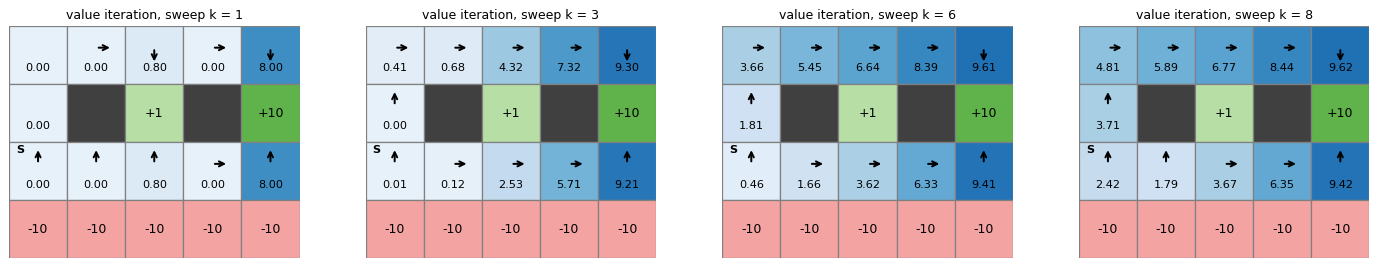

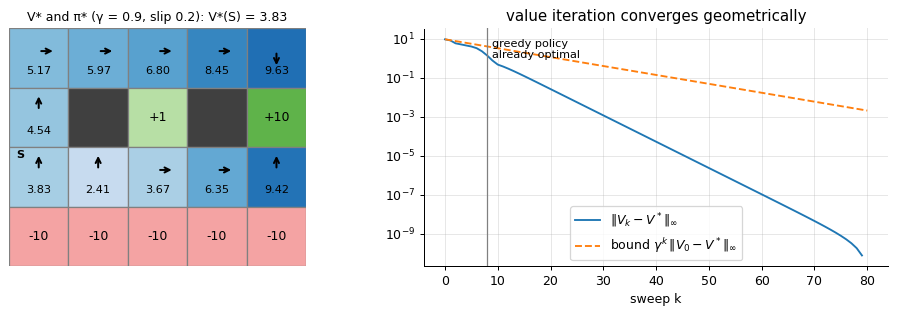

In [10]:
err_vi = np.array([np.abs(h - V_star).max() for h in hist_vi])
stable = next(k for k in range(len(hist_vi)) if all(
    np.array_equal((R + GAMMA * P @ hist_vi[j]).argmax(1)[dec], pi_star[dec]) for j in range(k, len(hist_vi))))
print(f"the greedy policy of V_k is optimal from sweep k = {stable} on, while max error is still {err_vi[stable]:.2f}")
print("error after k sweeps:", {k: round(float(err_vi[k]), 3) for k in (0, 1, 5, 10, 20, 50)})
assert np.all(err_vi <= err_vi[0] * GAMMA ** np.arange(len(err_vi)) + 1e-12)      # the contraction bound

fig, axes = plt.subplots(1, 4, figsize=(16, 3.0))
def greedy_or_tie(Q):
    """argmax_a Q(s, a), or -1 where all actions are (numerically) equal."""
    return np.where(np.ptp(Q, axis=1) < 1e-9, -1, Q.argmax(1))
for ax, k in zip(axes, (1, 3, 6, stable)):
    draw_grid(ax, V=hist_vi[k], policy=greedy_or_tie(R + GAMMA * P @ hist_vi[k]), title=f"value iteration, sweep k = {k}")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
draw_grid(axes[0], V=V_star, policy=pi_star, title=f"V* and π* (γ = 0.9, slip 0.2): V*(S) = {V_star[START]:.2f}")
axes[1].semilogy(err_vi[:-1], label=r"$\|V_k - V^*\|_\infty$")      # the last sweep is V* itself (error 0)
axes[1].semilogy(err_vi[0] * GAMMA ** np.arange(len(err_vi)), "--", label=r"bound $\gamma^k\,\|V_0 - V^*\|_\infty$")
axes[1].axvline(stable, color="gray", lw=1); axes[1].text(stable + 1, 1, "greedy policy\nalready optimal", fontsize=9)
axes[1].set_xlabel("sweep k"); axes[1].legend(); axes[1].set_title("value iteration converges geometrically")
plt.tight_layout(); plt.show()

**Things to notice.**

- Values spread backwards from the exits, about one cell per sweep: after sweep 1 only the cells next to an exit have a value (no arrow where all actions are still tied), and S gets its first non-zero value at sweep 3.
- The greedy policy of $V_k$ is already optimal from sweep 8 on, when $V_8$ is still 1.41 away from $V^*$. **Policies converge long before values.** That is why policy iteration, which jumps from policy to policy, needs so few iterations.
- The optimal policy takes the long way: up from S to the top row, across, and down into +10 (7 moves instead of 5 along the cliff). With a 10 % chance of slipping sideways at every step, walking along the cliff costs too much. The cell next to S pushes up against the wall: it can only slip sideways, never down into the cliff.
- The bound $\gamma^k \|V_0 - V^*\|_\infty = 9.63 \cdot 0.9^k$ is loose: at $k = 10$ the error is 0.48, not 3.36, because many trajectories end soon and stop accumulating error.

## 5. The discount and the slip shape the optimal policy

The optimal policy is not a property of the grid alone. It depends on the discount, on the noise and on the rewards we chose. We solve six variants with value iteration and draw the most likely path from S (following the intended moves).

γ = 0.3, slip = 0.0, living +0:  V(S) =  0.090, path of 3 moves ends at the +1 exit
γ = 0.3, slip = 0.2, living +0:  V(S) =  0.005, path of 5 moves ends at the +1 exit
γ = 0.9, slip = 0.0, living +0:  V(S) =  6.561, path of 5 moves ends at the +10 exit
γ = 0.9, slip = 0.2, living +0:  V(S) =  3.832, path of 7 moves ends at the +10 exit
γ = 0.9, slip = 0.2, living +1:  V(S) =  9.875, path of 5 moves ends at no exit (the agent never leaves)
γ = 0.9, slip = 0.2, living -2:  V(S) = -5.183, path of 3 moves ends at the +1 exit


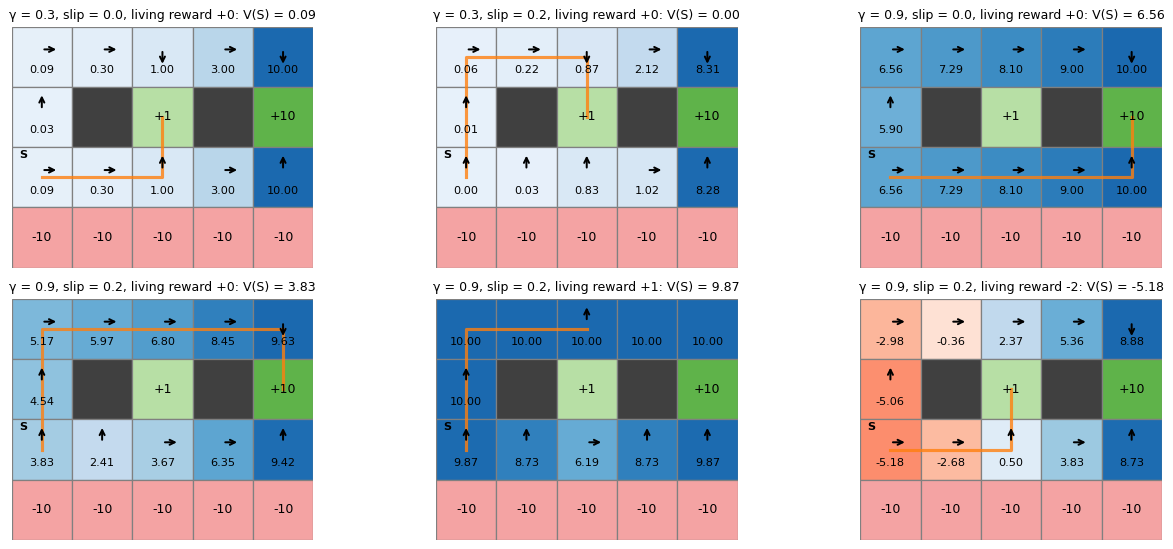

In [11]:
def greedy_path(pi_det, max_len=30):
    """Follow the intended moves of a deterministic policy from S (the most likely path)."""
    s, path = START, [START]
    for _ in range(max_len):
        if TERMINAL[s]: break
        r, c = CELLS[s]; dr, dc = MOVES[pi_det[s]]
        rr, cc = r + dr, c + dc
        if 0 <= rr < N_ROWS and 0 <= cc < N_COLS and LAYOUT[rr][cc] != "#": s = STATE[(rr, cc)]
        path.append(s)
        if len(path) > 3 and path[-1] == path[-2]: break           # pushing against a wall
    return path

cases = [(0.3, 0.0, 0.0), (0.3, 0.2, 0.0), (0.9, 0.0, 0.0), (0.9, 0.2, 0.0), (0.9, 0.2, 1.0), (0.9, 0.2, -2.0)]
fig, axes = plt.subplots(2, 3, figsize=(15, 6.2))
for ax, (g, slip, live) in zip(axes.ravel(), cases):
    Pc, Rc = make_mdp(slip, live)
    Vc, Qc, _ = value_iteration(Pc, Rc, g)
    pc = Qc.argmax(1); path = greedy_path(pc)
    end = LAYOUT[CELLS[path[-1]][0]][CELLS[path[-1]][1]]
    draw_grid(ax, V=Vc, policy=greedy_or_tie(Qc), path=path, vmax=max(1, Vc.max()),
              title=f"γ = {g}, slip = {slip}, living reward {live:+g}: V(S) = {Vc[START]:.2f}")
    print(f"γ = {g}, slip = {slip}, living {live:+g}:  V(S) = {Vc[START]:6.3f}, path of {len(path) - 1} moves ends at",
          {"A": "the +1 exit", "B": "the +10 exit"}.get(end, "no exit (the agent never leaves)"))
plt.tight_layout(); plt.show()

In [12]:
gammas = np.round(np.arange(0.05, 1.0, 0.005), 3)
P0, R0 = make_mdp(0.0)
far = []
for g in gammas:
    _, Qg, _ = value_iteration(P0, R0, g)
    end = CELLS[greedy_path(Qg.argmax(1))[-1]]
    far.append(LAYOUT[end[0]][end[1]] == "B")
g_switch = gammas[np.argmax(far)]
print(f"slip 0: the agent at S switches from +1 to +10 at γ ≈ {g_switch}   (theory: 10 γ⁴ > γ² ⇔ γ > 1/√10 = {1 / np.sqrt(10):.3f})")
assert abs(g_switch - 1 / np.sqrt(10)) < 0.006

slip 0: the agent at S switches from +1 to +10 at γ ≈ 0.32   (theory: 10 γ⁴ > γ² ⇔ γ > 1/√10 = 0.316)


**What just happened?**

| γ | slip | reward per move | V(S) | path from S |
|---|---|---|---|---|
| 0.3 | 0 | 0 | 0.090 | 3 moves along the cliff to +1 |
| 0.3 | 0.2 | 0 | 0.005 | 5 moves, the safe way, to +1 |
| 0.9 | 0 | 0 | 6.561 | 5 moves along the cliff to +10 |
| 0.9 | 0.2 | 0 | 3.832 | 7 moves, the safe way, to +10 |
| 0.9 | 0.2 | +1 | 9.875 | never leaves |
| 0.9 | 0.2 | −2 | −5.183 | 3 moves along the cliff to +1 |

- **γ decides near or far.** With slip 0, +1 is 3 moves away and its reward arrives on the 3rd move, so it is worth $\gamma^2 \cdot 1$; +10 is worth $\gamma^4 \cdot 10$. Far wins when $10\gamma^4 > \gamma^2$, that is $\gamma > 1/\sqrt{10} = 0.316$; the sweep finds the switch at γ ≈ 0.32. A small γ makes the agent short-sighted.
- **Noise decides risky or safe.** With slip 0.2 the policy leaves the cliff edge in both cases: 5 moves instead of 3 to +1, 7 instead of 5 to +10.
- **The reward per move is part of the task.** With +1 per move, wandering forever is worth up to $1/(1 - \gamma) = 10$, as much as the +10 exit and without the risk, so the agent never leaves. With −2 per move every step hurts, and the agent rushes to the nearest exit along the cliff even on the slippery floor. Same grid, different rewards, opposite behaviour: an RL agent optimises what you reward, not what you meant.

## 6. Learning from experience: Monte Carlo vs TD(0)

Planning needed $P$ and $R$. Usually we do not have them: we only see episodes. **Model-free** methods estimate values from samples.

- **Monte Carlo** (MC) waits until the end of the episode and moves $V(S_t)$ towards the return it observed: $V(S_t) \leftarrow V(S_t) + \alpha\,\big(G_t - V(S_t)\big)$. $G_t$ is an unbiased sample of $V^\pi(S_t)$ but a noisy one: it contains all the randomness of the rest of the episode.
- **Temporal difference** learning, TD(0), updates after every step. It replaces the rest of the return by its own estimate of the next state's value (**bootstrapping**):
$$
V(S_t) \leftarrow V(S_t) + \alpha\,\delta_t, \qquad \delta_t = R_{t+1} + \gamma\, V(S_{t+1}) - V(S_t).
$$
The **TD error** $\delta_t$ compares a prediction, $V(S_t)$, with a slightly better-informed prediction made one step later, $R_{t+1} + \gamma V(S_{t+1})$. This target is biased (it uses the current, imperfect $V$) but has low variance (one reward, one transition). TD also works online and in tasks that never end. It is the sampled version of the Bellman expectation equation.

The classic test is the **random walk** of Sutton and Barto (Example 6.2): states A to E in a row, start at C, move left or right with probability 1/2, reward 1 for leaving on the right, 0 on the left, $\gamma = 1$. Then $V(s)$ is the probability of leaving on the right, $1/6, 2/6, \dots, 5/6$ for A to E (a fair gambler's ruin). All estimates start at 0.5.

First three scripted episodes with $\alpha = 0.1$ (the ones of the slides), then the RMS error over 100 episodes, averaged over 100 runs.

In [13]:
TRUE_RW = np.arange(1, 6) / 6                      # true values of A..E: probability of ending on the right

def rw_episode(rng):
    """Random walk A-B-C-D-E (states 0..4), start at C, step left or right with prob. 1/2.
    Returns the visited states and the final reward (1 at the right end, 0 at the left end)."""
    s, traj = 2, [2]
    while True:
        s += 1 if rng.random() < 0.5 else -1
        if s < 0: return traj, 0.0
        if s > 4: return traj, 1.0
        traj.append(s)

def td0_update(V, traj, reward, alpha, gamma=1.0):
    """TD(0) along one episode: V(s) += α (r + γ V(s') − V(s)); terminal states have value 0."""
    for i, s in enumerate(traj):
        r, v_next = (0.0, V[traj[i + 1]]) if i + 1 < len(traj) else (reward, 0.0)
        V[s] += alpha * (r + gamma * v_next - V[s])

def mc_update(V, traj, reward, alpha):
    """Constant-α Monte Carlo: V(s) += α (G − V(s)); with γ = 1 and a single final reward, G = reward."""
    for s in traj:
        V[s] += alpha * (reward - V[s])

def rms_curve(update, alpha, n_episodes=100, runs=100):
    errs = np.zeros((runs, n_episodes + 1))
    for run in range(runs):
        rng, V = np.random.default_rng(run), np.full(5, 0.5)
        errs[run, 0] = np.sqrt(np.mean((V - TRUE_RW) ** 2))
        for e in range(n_episodes):
            update(V, *rw_episode(rng), alpha)
            errs[run, e + 1] = np.sqrt(np.mean((V - TRUE_RW) ** 2))
    return errs.mean(0)

# three scripted episodes, the ones of the slides
V = np.full(5, 0.5)
for ep, (traj, rew) in enumerate([([2, 3, 4], 1.0), ([2, 3, 4, 3, 4], 1.0), ([2, 1, 0], 0.0)], 1):
    td0_update(V, traj, rew, alpha=0.1)
    print(f"episode {ep}: {'-'.join('ABCDE'[s] for s in traj)} -> reward {rew:g}   V(A..E) = {V.round(4)}")

curves = {f"TD(0), α = {a}": rms_curve(td0_update, a) for a in (0.05, 0.1, 0.15)}
curves.update({f"MC, α = {a}": rms_curve(mc_update, a) for a in (0.01, 0.02, 0.03, 0.04)})
for name, cv in curves.items():
    print(f"{name:16s} RMS error after 10, 25, 100 episodes: {cv[10]:.3f} {cv[25]:.3f} {cv[100]:.3f}")

episode 1: C-D-E -> reward 1   V(A..E) = [0.5  0.5  0.5  0.5  0.55]
episode 2: C-D-E-D-E -> reward 1   V(A..E) = [0.5   0.5   0.5   0.509 0.591]
episode 3: C-B-A -> reward 0   V(A..E) = [0.45  0.5   0.5   0.509 0.591]


TD(0), α = 0.05  RMS error after 10, 25, 100 episodes: 0.175 0.110 0.036
TD(0), α = 0.1   RMS error after 10, 25, 100 episodes: 0.129 0.057 0.057
TD(0), α = 0.15  RMS error after 10, 25, 100 episodes: 0.097 0.060 0.073
MC, α = 0.01     RMS error after 10, 25, 100 episodes: 0.213 0.183 0.097
MC, α = 0.02     RMS error after 10, 25, 100 episodes: 0.199 0.156 0.085
MC, α = 0.03     RMS error after 10, 25, 100 episodes: 0.190 0.143 0.096
MC, α = 0.04     RMS error after 10, 25, 100 episodes: 0.184 0.140 0.109


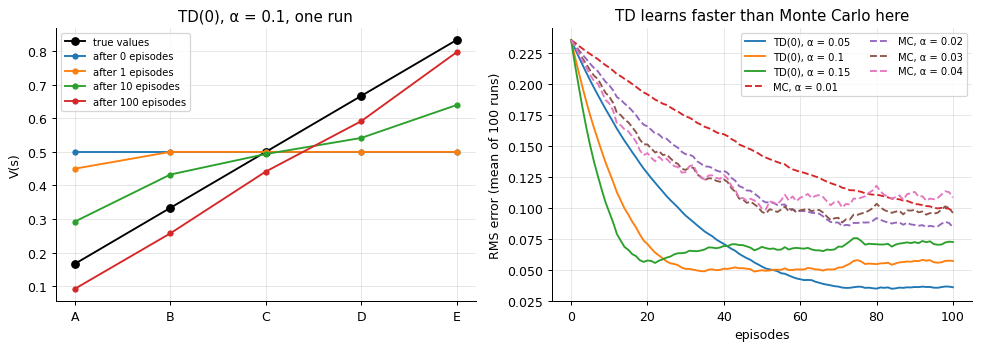

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rng, V = np.random.default_rng(0), np.full(5, 0.5)
axes[0].plot(range(5), TRUE_RW, "k-o", label="true values")
for e in range(101):
    if e in (0, 1, 10, 100): axes[0].plot(range(5), V, "-o", ms=4, label=f"after {e} episodes")
    td0_update(V, *rw_episode(rng), 0.1)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(list("ABCDE")); axes[0].set_ylabel("V(s)")
axes[0].set_title("TD(0), α = 0.1, one run"); axes[0].legend(fontsize=8)
for name, cv in curves.items():
    axes[1].plot(cv, label=name, ls="-" if name.startswith("TD") else "--")
axes[1].set_xlabel("episodes"); axes[1].set_ylabel("RMS error (mean of 100 runs)"); axes[1].legend(fontsize=8, ncol=2)
axes[1].set_title("TD learns faster than Monte Carlo here")
plt.tight_layout(); plt.show()

**What just happened?** Episode 1 (C-D-E, then out on the right) changes only $V(E)$: $0.5 + 0.1\,(1 + 0 - 0.5) = 0.55$. The other TD errors are $0 + 0.5 - 0.5 = 0$: nothing surprising happened there yet. Episode 2 (C-D-E-D-E) carries the news one step back: at D, $\delta = 0 + 0.55 - 0.5 = 0.05$ and $V(D) = 0.505$; after the whole episode $V(D) = 0.509$ and $V(E) = 0.591$. Episode 3 (C-B-A, out on the left) lowers $V(A)$ to $0.5 + 0.1\,(0 + 0 - 0.5) = 0.45$. TD moves information back one step per visit; MC would move every visited state towards the final reward at once.

Over 100 episodes TD beats MC at every step size we tried: after 25 episodes the best TD has an RMS error of 0.057 against 0.140 for the best MC. The curves then flatten, and rise slightly for the larger step sizes: with a constant $\alpha$ the estimates keep reacting to the latest episodes and fluctuate around the truth. A decreasing step size, such as $\alpha = 1/N(s)$, removes that floor.

## 7. SARSA vs Q-learning on the cliff

To find a good policy without a model we learn **action values** $Q(s, a)$: choosing $\arg\max_a Q(s, a)$ needs no model, while choosing an action from $V$ would need $P$. Both methods below act **ε-greedily** (a random action with probability $\varepsilon$, else the greedy one) and make a TD update after every step,
$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha\,\big[\text{target} - Q(S_t, A_t)\big].
$$
They differ only in the target:

- **SARSA** (from the quintuple $S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1}$): target $R_{t+1} + \gamma\, Q(S_{t+1}, A_{t+1})$, with $A_{t+1}$ the action the agent will actually take next. It learns the value of the policy it follows, exploration included: **on-policy**.
- **Q-learning** (Watkins, 1989): target $R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a')$. It learns the value of the greedy policy, whatever the agent actually does: **off-policy**. It is the sampled version of value iteration.

**Cliff walking** (Sutton and Barto, Example 6.6): a 4 × 12 grid, start at the bottom left, goal at the bottom right, and the cells between them are a cliff. Every move costs −1; stepping into the cliff costs −100 and sends the agent back to the start. $\gamma = 1$, $\alpha = 0.5$, $\varepsilon = 0.1$, 500 episodes, 50 runs. The shortest path, 13 moves, runs right along the edge.

In [15]:
CR, CC = 4, 12                                           # cliff walking: 4 × 12 grid
C_START, C_GOAL = 3 * CC + 0, 3 * CC + 11

def cliff_step(s, a):
    """−1 per move; stepping into the cliff (bottom row between S and G) costs −100 and sends you back to S."""
    r, c = divmod(s, CC)
    r = min(max(r + MOVES[a][0], 0), CR - 1); c = min(max(c + MOVES[a][1], 0), CC - 1)
    if r == 3 and 1 <= c <= 10:
        return C_START, -100.0, False
    s2 = r * CC + c
    return s2, -1.0, s2 == C_GOAL

def eps_greedy(Q, s, eps, rng):
    if rng.random() < eps: return int(rng.integers(nA))
    return int(np.argmax(Q[s] + 1e-9 * rng.random(nA)))   # random tie-breaking

def td_control(method, episodes=500, alpha=0.5, eps=0.1, gamma=1.0, seed=0):
    """SARSA (target uses the next action actually taken) or Q-learning (target uses the max)."""
    rng, Q, returns = np.random.default_rng(seed), np.zeros((CR * CC, nA)), np.zeros(episodes)
    for e in range(episodes):
        s, done, G = C_START, False, 0.0
        a = eps_greedy(Q, s, eps, rng)
        while not done:
            s2, r, done = cliff_step(s, a); G += r
            a2 = eps_greedy(Q, s2, eps, rng)
            nxt = 0.0 if done else (Q[s2, a2] if method == "sarsa" else Q[s2].max())
            Q[s, a] += alpha * (r + gamma * nxt - Q[s, a])
            s, a = s2, a2
        returns[e] = G
    return Q, returns

def cliff_greedy_path(Q):
    """Follow argmax_a Q from S. Returns the path and whether it reaches G (False: the greedy policy loops)."""
    s, path = C_START, [C_START]
    while s != C_GOAL:
        s = cliff_step(s, int(Q[s].argmax()))[0]
        if s in path: return path + [s], False
        path.append(s)
    return path, True

t0 = time.time()
cliff = {}
for method in ("sarsa", "q"):
    runs = [td_control(method, seed=k) for k in range(50)]
    greedy = [cliff_greedy_path(Q) for Q, _ in runs]
    cliff[method] = dict(returns=np.array([r for _, r in runs]), paths=[tuple(p) for p, ok in greedy if ok], loops=sum(not ok for _, ok in greedy))
print(f"2 methods × 50 runs × 500 episodes in {time.time() - t0:.1f} s")
for method, name in (("sarsa", "SARSA"), ("q", "Q-learning")):
    ret, paths, loops = cliff[method]["returns"], cliff[method]["paths"], cliff[method]["loops"]
    lens = np.array([len(p) - 1 for p in paths])
    print(f"{name:10s}: mean return over the last 100 episodes (while exploring, ε = 0.1): {ret[:, -100:].mean():6.1f}"
          f" | greedy path to G (moves: runs): { {int(k): int(v) for k, v in zip(*np.unique(lens, return_counts=True))} }, loops: {loops} runs")

2 methods × 50 runs × 500 episodes in 4.3 s
SARSA     : mean return over the last 100 episodes (while exploring, ε = 0.1):  -29.2 | greedy path to G (moves: runs): {17: 35, 19: 4}, loops: 11 runs
Q-learning: mean return over the last 100 episodes (while exploring, ε = 0.1):  -49.7 | greedy path to G (moves: runs): {13: 50}, loops: 0 runs


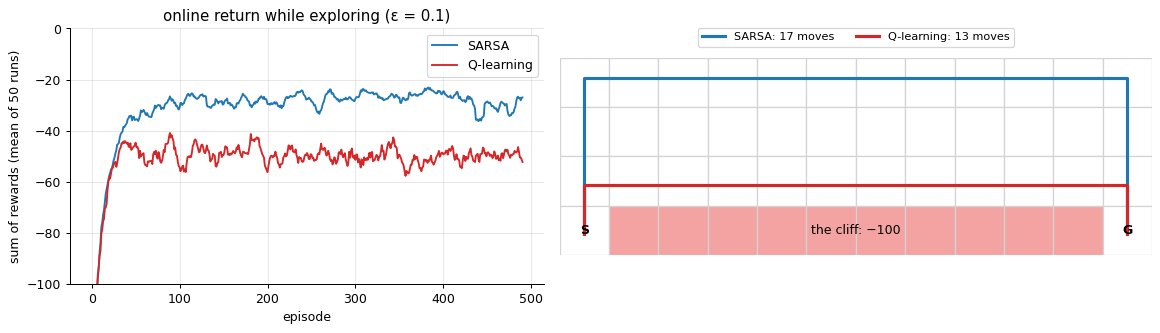

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 1.25]})
for method, name, col in (("sarsa", "SARSA", "tab:blue"), ("q", "Q-learning", "tab:red")):
    m = cliff[method]["returns"].mean(0)
    axes[0].plot(np.convolve(m, np.ones(10) / 10, mode="valid"), color=col, label=name)
axes[0].set_ylim(-100, 0); axes[0].set_xlabel("episode"); axes[0].set_ylabel("sum of rewards (mean of 50 runs)")
axes[0].set_title("online return while exploring (ε = 0.1)"); axes[0].legend()
ax = axes[1]
for r in range(CR):
    for c in range(CC):
        fc = "#f4a3a3" if (r == 3 and 1 <= c <= 10) else "white"
        ax.add_patch(plt.Rectangle((c, -r - 1), 1, 1, facecolor=fc, edgecolor="lightgray"))
ax.text(0.5, -3.5, "S", ha="center", va="center", fontweight="bold"); ax.text(11.5, -3.5, "G", ha="center", va="center", fontweight="bold")
ax.text(6, -3.5, "the cliff: −100", ha="center", va="center")
for method, name, col, off in (("sarsa", "SARSA", "tab:blue", 0.08), ("q", "Q-learning", "tab:red", -0.08)):
    paths = cliff[method]["paths"]; p = max(set(paths), key=paths.count)
    xy = np.array([(s % CC + 0.5, -(s // CC) - 0.5 + off) for s in p])
    ax.plot(xy[:, 0], xy[:, 1], color=col, lw=2.5, label=f"{name}: {len(p) - 1} moves")
ax.set_xlim(0, CC); ax.set_ylim(-CR, 0); ax.set_aspect("equal"); ax.axis("off"); ax.legend(loc="upper center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, 1.18))
plt.tight_layout(); plt.show()

**What just happened?** The classic result. Q-learning learns the optimal path along the edge, 13 moves, in all 50 runs. But it walks that path while exploring with $\varepsilon = 0.1$, and one random step next to the cliff is a fall: its online return is −49.7 per episode. SARSA's target includes the exploratory steps, so it learns that the edge is dangerous *for an agent that explores*, and it walks along the top of the grid: 17 moves in 35 of the 50 runs, 19 in 4. Its online return is better, −29.2. Run greedily after training, Q-learning's path is the better one (−13 against −17).

In the other 11 SARSA runs the greedy path never reaches G: at some cell it points into a wall or back to where it came from, and it loops. With a constant, large step size ($\alpha = 0.5$) the estimates keep fluctuating, and in cells where several actions have nearly the same value (for example −13.2 for "up" against the border and −13.6 for "right" on the top row) the greedy choice is noise. This does not hurt SARSA while it explores, because random moves break the loops, but it is a reminder that a greedy policy read from noisy values needs to be checked. A decreasing $\alpha$ fixes it.

Which is right depends on whether the exploration continues when it matters. A robot that keeps making random moves should learn like SARSA; a policy that will be deployed without exploration, like Q-learning. With $\varepsilon$ decreasing to 0 over time, both converge to the optimal path.

## 8. Policy gradients: REINFORCE with a baseline on CartPole

Value-based methods derive the policy from $Q$. **Policy-gradient** methods parametrise the policy directly, $\pi_\theta(a \mid s)$ (here a softmax over the outputs of a small MLP), and do gradient ascent on the expected return
$$
J(\theta) = \mathbb E_{\tau \sim \pi_\theta}[R(\tau)], \qquad \tau = (S_0, A_0, R_1, S_1, A_1, R_2, \dots), \qquad R(\tau) = \sum_t \gamma^t R_{t+1}.
$$
They handle continuous actions and stochastic policies naturally, and they are the family of PPO and RLHF.

**The log-derivative trick.** Since $\nabla_\theta p_\theta = p_\theta\, \nabla_\theta \log p_\theta$,
$$
\nabla_\theta J = \nabla_\theta \sum_\tau p_\theta(\tau)\, R(\tau) = \sum_\tau p_\theta(\tau)\, \nabla_\theta \log p_\theta(\tau)\, R(\tau) = \mathbb E_{\tau \sim \pi_\theta}\big[R(\tau)\, \nabla_\theta \log p_\theta(\tau)\big].
$$
An expectation can be estimated by sampling: play episodes and average. Moreover $p_\theta(\tau) = p(S_0) \prod_t \pi_\theta(A_t \mid S_t)\, P(S_{t+1} \mid S_t, A_t)$, so in $\log p_\theta(\tau)$ the unknown dynamics are terms without $\theta$, and they drop out of the gradient:
$$
\nabla_\theta \log p_\theta(\tau) = \sum_t \nabla_\theta \log \pi_\theta(A_t \mid S_t).
$$
An action cannot change the rewards that came before it, so each term only needs the rewards after it, the **reward-to-go** $G_t$. This is **REINFORCE** (Williams, 1992):
$$
\nabla_\theta J \approx \frac{1}{B} \sum_{\text{episodes}} \sum_t G_t\, \nabla_\theta \log \pi_\theta(A_t \mid S_t).
$$
In code we minimise $-\sum_t G_t \log \pi_\theta(A_t \mid S_t)$ with autograd: a cross-entropy loss whose "label" is the action the agent took, weighted by how well things went afterwards.

**Baselines.** Subtracting any $b(s)$ that does not depend on the action keeps the estimate unbiased:
$$
\mathbb E_{a \sim \pi_\theta}\big[b(s)\, \nabla_\theta \log \pi_\theta(a \mid s)\big] = b(s) \sum_a \nabla_\theta \pi_\theta(a \mid s) = b(s)\, \nabla_\theta \sum_a \pi_\theta(a \mid s) = b(s)\, \nabla_\theta 1 = 0 .
$$
A good baseline, $b(s) \approx V(s)$, turns the weight into the **advantage** $G_t - V(S_t)$: was this better or worse than usual? Same mean, much smaller variance.

First a check on a 3-armed bandit with a softmax policy, where the exact gradient is known. With $\pi = \text{softmax}(\theta)$ and mean rewards $\bar r$, $J = \sum_a \pi_a \bar r_a$ and $\partial J / \partial \theta_b = \pi_b (\bar r_b - J)$. One sample gives $r\, \nabla_\theta \log \pi_\theta(a) = r\, (\mathbf e_a - \pi)$.

In [17]:
theta = torch.tensor([0.5, 0.0, -0.5], requires_grad=True)       # softmax policy over 3 actions
r_mean = torch.tensor([1.0, 2.0, 0.0])                            # mean reward of each action (noise sd 1)
pi = torch.softmax(theta, 0)
J = (pi * r_mean).sum()                                            # J(θ) = Σ_a π_θ(a) r̄(a)
J.backward()
exact = theta.grad.clone()
with torch.no_grad():
    formula = pi * (r_mean - J)                                    # ∂J/∂θ_b = π_b (r̄_b − J)
rng = np.random.default_rng(0)
n = 200_000
a = rng.choice(3, size=n, p=pi.detach().numpy())
r = r_mean.numpy()[a] + rng.normal(size=n)                         # noisy rewards
score = np.eye(3)[a] - pi.detach().numpy()                         # ∇_θ log π_θ(a) = e_a − π for a softmax
g_plain = r[:, None] * score                                       # REINFORCE, one sample each
g_base = (r - J.item())[:, None] * score                           # same, with the baseline b = J
print("exact gradient (autograd)     :", exact.numpy().round(4))
print("closed form π_b (r̄_b − J)     :", formula.numpy().round(4))
print("REINFORCE mean of 200k samples:", g_plain.mean(0).round(4), "  with baseline:", g_base.mean(0).round(4))
print(f"total variance per sample: without baseline {g_plain.var(0).sum():.3f}, with baseline {g_base.var(0).sum():.3f}"
      f"  (÷ {g_plain.var(0).sum() / g_base.var(0).sum():.1f})")
assert torch.allclose(exact, formula) and np.allclose(g_plain.mean(0), exact.numpy(), atol=0.01) and np.allclose(g_base.mean(0), exact.numpy(), atol=0.01)

exact gradient (autograd)     : [-0.061  0.27  -0.209]
closed form π_b (r̄_b − J)     : [-0.061  0.27  -0.209]
REINFORCE mean of 200k samples: [-0.061  0.27  -0.209]   with baseline: [-0.063  0.27  -0.207]
total variance per sample: without baseline 1.633, with baseline 0.916  (÷ 1.8)


**What just happened?** Autograd, the closed form and the average of 200,000 single-sample REINFORCE estimates agree: $(-0.061, 0.270, -0.209)$. With the baseline $b = J$ the average is the same (unbiased), but the variance per sample drops from 1.63 to 0.92, a factor 1.8: the same precision with about half as many samples.

**CartPole.** A pole is hinged on a cart; every 20 ms we push the cart left or right with 10 N to keep the pole up. State $(x, \dot x, \theta, \dot\theta)$; reward +1 per step; the episode ends when the pole tilts more than 12°, when the cart leaves the ±2.4 m track, or after 500 steps. No library is needed: the equations of motion (Barto, Sutton and Anderson, 1983, with the constants of Gymnasium's `CartPole-v1`) are
$$
\ddot\theta = \frac{g \sin\theta - \cos\theta\, \dfrac{F + m_p l\, \dot\theta^2 \sin\theta}{m_c + m_p}}{l \left(\dfrac{4}{3} - \dfrac{m_p \cos^2\theta}{m_c + m_p}\right)}, \qquad
\ddot x = \frac{F + m_p l\, (\dot\theta^2 \sin\theta - \ddot\theta \cos\theta)}{m_c + m_p},
$$
with $g = 9.8$, cart mass $m_c = 1$, pole mass $m_p = 0.1$, half pole length $l = 0.5$, force $F = \pm 10$, integrated with Euler steps of 0.02 s. The class below simulates many carts at once with NumPy arrays.

In [18]:
class CartPole:
    """CartPole (Barto, Sutton & Anderson, 1983) with the constants of Gymnasium's CartPole-v1, for n carts at once.
    State (x, ẋ, θ, θ̇); action 0 pushes left, 1 pushes right with 10 N; reward +1 per step while alive;
    the episode ends when |x| > 2.4 m, |θ| > 12° or after 500 steps."""
    g, m_cart, m_pole, half_len, force, tau = 9.8, 1.0, 0.1, 0.5, 10.0, 0.02
    x_max, th_max, T_max = 2.4, 12 * np.pi / 180, 500

    def __init__(self, n, seed=0):
        self.n, self.rng = n, np.random.default_rng(seed)

    def reset(self):
        self.s, self.t = self.rng.uniform(-0.05, 0.05, size=(self.n, 4)), 0
        self.alive = np.ones(self.n, dtype=bool)
        return self.s.copy()

    def step(self, a):
        x, x_dot, th, th_dot = self.s.T
        f = np.where(a == 1, self.force, -self.force)
        cos, sin, M, ml = np.cos(th), np.sin(th), self.m_cart + self.m_pole, self.m_pole * self.half_len
        tmp = (f + ml * th_dot ** 2 * sin) / M
        th_acc = (self.g * sin - cos * tmp) / (self.half_len * (4 / 3 - self.m_pole * cos ** 2 / M))
        x_acc = tmp - ml * th_acc * cos / M
        self.s = np.stack([x + self.tau * x_dot, x_dot + self.tau * x_acc,
                           th + self.tau * th_dot, th_dot + self.tau * th_acc], 1)   # explicit Euler, 20 ms
        self.t += 1
        reward = self.alive.astype(float)
        self.alive &= (np.abs(self.s[:, 0]) <= self.x_max) & (np.abs(self.s[:, 2]) <= self.th_max)
        return self.s.copy(), reward, (~self.alive) | (self.t >= self.T_max)

def episode_lengths(policy_fn, n=1000, seed=0):
    env = CartPole(n, seed); s = env.reset(); steps = np.zeros(n)
    while True:
        s, rwd, done = env.step(policy_fn(s)); steps += rwd
        if done.all(): return steps

rng = np.random.default_rng(0)
L_rand = episode_lengths(lambda s: rng.integers(0, 2, len(s)))
L_left = episode_lengths(lambda s: np.zeros(len(s), dtype=int))
L_hand = episode_lengths(lambda s: (s[:, 2] + 0.5 * s[:, 3] > 0).astype(int))      # push towards where the pole falls
print(f"random actions : mean episode length {L_rand.mean():.1f}  (expected ≈ 22 for CartPole)")
print(f"always left    : mean episode length {L_left.mean():.1f}")
print(f"hand-made rule (push right if θ + 0.5 θ̇ > 0): mean length {L_hand.mean():.1f}")

random actions : mean episode length 22.3  (expected ≈ 22 for CartPole)
always left    : mean episode length 9.4
hand-made rule (push right if θ + 0.5 θ̇ > 0): mean length 500.0


Random actions keep the pole up for 22.3 steps on average (the usual figure for CartPole is about 22), always pushing left for 9.4. A one-line rule, push towards the side the pole is falling to, already balances for the full 500 steps: CartPole is easy if you know the physics. The point is that REINFORCE has to discover such a rule from the reward alone.

Settings: policy MLP 4 → 32 → 2 with tanh, 8 episodes per update, Adam with learning rate 0.01, $\gamma = 0.99$, 100 updates (800 episodes). The baseline is a second MLP $V_w(s)$, fitted to the returns by least squares in the same loop. 5 seeds per variant, about a minute in total.

In [19]:
def reinforce(baseline, seed, n_updates=100, batch=8, lr=0.01, gamma=0.99, hidden=32):
    """REINFORCE on CartPole: `batch` episodes per update, policy MLP 4 -> 32 -> 2.
    baseline=True subtracts a learned value V_w(s) (MLP 4 -> 32 -> 1, trained on the returns by MSE)."""
    torch.manual_seed(seed)
    env = CartPole(batch, seed)
    policy = nn.Sequential(nn.Linear(4, hidden), nn.Tanh(), nn.Linear(hidden, 2))
    value = nn.Sequential(nn.Linear(4, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    opt_pi, opt_v = torch.optim.Adam(policy.parameters(), lr=lr), torch.optim.Adam(value.parameters(), lr=lr)
    lengths = []
    for _ in range(n_updates):
        s = env.reset(); S, A, ALIVE = [], [], []
        while True:                                            # play `batch` episodes in parallel
            with torch.no_grad():
                a = torch.distributions.Categorical(logits=policy(torch.as_tensor(s, dtype=torch.float32))).sample().numpy()
            S.append(s); A.append(a); ALIVE.append(env.alive.copy())
            s, _, done = env.step(a)
            if done.all(): break
        S, A, ALIVE = np.array(S), np.array(A), np.array(ALIVE)            # (T, batch, ...)
        lengths += ALIVE.sum(0).tolist()
        G, g = np.zeros(ALIVE.shape), np.zeros(batch)                       # reward-to-go G_t = Σ_k γ^k r_{t+k+1}
        for t in reversed(range(len(S))):
            g = ALIVE[t] * (1.0 + gamma * g); G[t] = g
        St = torch.as_tensor(S[ALIVE], dtype=torch.float32)
        At, Gt = torch.as_tensor(A[ALIVE]), torch.as_tensor(G[ALIVE], dtype=torch.float32)
        logp = torch.distributions.Categorical(logits=policy(St)).log_prob(At)
        if baseline:
            v = value(St).squeeze(-1)
            adv = (Gt - v).detach()                                         # advantage estimate G_t − V(s_t)
            opt_v.zero_grad(); ((v - Gt) ** 2).mean().backward(); opt_v.step()
        else:
            adv = Gt
        loss = -(logp * adv).sum() / batch                                  # minus the policy-gradient objective
        opt_pi.zero_grad(); loss.backward(); opt_pi.step()
    return np.array(lengths), policy

t0 = time.time()
pg = {b: [reinforce(b, seed) for seed in range(5)] for b in (False, True)}
print(f"2 variants × 5 seeds × 800 episodes in {time.time() - t0:.0f} s")
for b in (False, True):
    L = np.array([l for l, _ in pg[b]])
    print(f"{'with baseline   ' if b else 'without baseline'}: mean length of the last 100 episodes per seed {L[:, -100:].mean(1).round(0)}"
          f" -> mean {L[:, -100:].mean():.0f};  episodes 300-400: {L[:, 300:400].mean():.0f};  steps of experience per run: {L.sum(1).mean():,.0f}")

2 variants × 5 seeds × 800 episodes in 52 s
without baseline: mean length of the last 100 episodes per seed [486. 363. 380. 454. 480.] -> mean 433;  episodes 300-400: 217;  steps of experience per run: 202,403
with baseline   : mean length of the last 100 episodes per seed [484. 491. 487. 497. 495.] -> mean 491;  episodes 300-400: 289;  steps of experience per run: 225,740


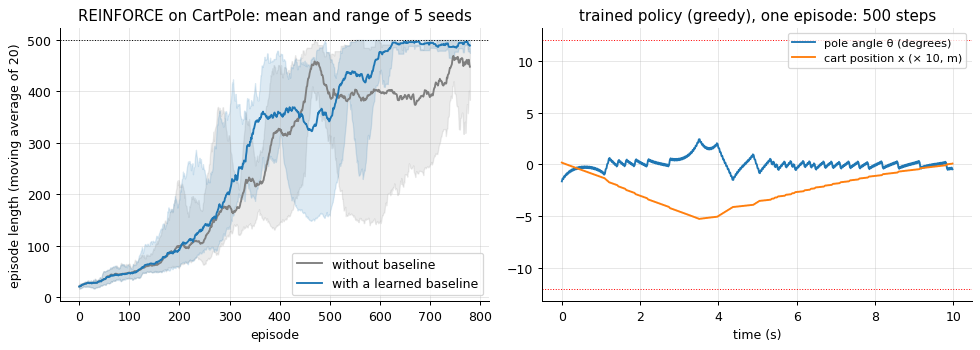

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for b, name, col in ((False, "without baseline", "tab:gray"), (True, "with a learned baseline", "tab:blue")):
    L = np.array([l for l, _ in pg[b]])
    sm = np.array([np.convolve(l, np.ones(20) / 20, mode="valid") for l in L])
    axes[0].plot(sm.mean(0), color=col, label=name)
    axes[0].fill_between(np.arange(sm.shape[1]), sm.min(0), sm.max(0), color=col, alpha=0.15)
axes[0].axhline(500, color="k", lw=0.8, ls=":"); axes[0].set_xlabel("episode"); axes[0].set_ylabel("episode length (moving average of 20)")
axes[0].set_title("REINFORCE on CartPole: mean and range of 5 seeds"); axes[0].legend()
policy = pg[True][0][1]
env = CartPole(1, seed=123); s = env.reset(); xs, ths = [], []
for _ in range(500):
    with torch.no_grad(): a = policy(torch.as_tensor(s, dtype=torch.float32)).argmax(1).numpy()
    s, _, done = env.step(a); xs.append(s[0, 0]); ths.append(np.degrees(s[0, 2]))
    if done[0]: break
axes[1].plot(np.arange(len(xs)) * 0.02, ths, label="pole angle θ (degrees)")
axes[1].plot(np.arange(len(xs)) * 0.02, np.array(xs) * 10, label="cart position x (× 10, m)")
axes[1].axhline(12, color="r", lw=0.8, ls=":"); axes[1].axhline(-12, color="r", lw=0.8, ls=":")
axes[1].set_xlabel("time (s)"); axes[1].set_title(f"trained policy (greedy), one episode: {len(xs)} steps"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**What just happened?** With the learned baseline all 5 seeds end close to the 500-step maximum (484 to 497 over the last 100 episodes, mean 491). Without it the same seeds end between 363 and 486 (mean 433), with a much wider spread. Both variants learn: Adam rescales the gradient, which hides part of the variance problem. But the baseline makes learning more reliable. The trained policy, run greedily, keeps the pole within a few degrees of vertical for the full 500 steps (10 seconds).

The cost: about 200,000 simulated steps per run for a task that a one-line rule solves. Policy gradients are sample-hungry, which is why simulators matter so much in RL. Actor–critic methods (A2C, PPO) learn the baseline by TD and update more often; PPO also reuses each batch for several epochs, with a clipped objective that stops the policy from moving too far (slides).

## 9. A tiny DQN: replay buffer and target network

Tabular Q-learning stores one number per state–action pair. With images or continuous states we need a function: $Q(s, a; \mathbf w)$, a neural network with one output per action. **DQN** (Mnih et al., 2015, human-level play on Atari games from pixels) minimises the squared TD error
$$
L(\mathbf w) = \Big(R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a'; \mathbf w^-) - Q(S_t, A_t; \mathbf w)\Big)^2
$$
with two tricks that make it stable:

- **experience replay**: transitions go into a buffer, and each update uses a random mini-batch from it. Consecutive transitions are strongly correlated; random batches are closer to the i.i.d. data that SGD expects, and every transition is reused many times;
- **target network** $\mathbf w^-$: a copy of the network, synchronised every few hundred steps, computes the targets. Without it every update moves the target it is chasing.

Function approximation, bootstrapping and off-policy learning together form the **deadly triad** (Sutton and Barto): each is harmless alone, but the three together can make the values diverge. The two tricks fight exactly that.

We train a DQN on the gridworld with one-hot states (18 inputs, 64 hidden units, 4 outputs), so that the result can be checked against $V^*$. Every 250 steps the network's greedy policy is evaluated **exactly** with the model of section 3. We compare with a naive version that trains on the last transition only, with no target network.

In [21]:
def dqn(seed, steps=5000, replay=True, target_every=200, batch=64, lr=1e-3, gamma=GAMMA, eval_every=250):
    """DQN on the gridworld with one-hot states. replay=False trains on the last transition only;
    target_every=1 means no separate target network. Every eval_every steps the greedy policy is evaluated exactly."""
    rng = np.random.default_rng(seed); torch.manual_seed(seed)
    env = GridEnv(P, R_NEXT, seed=1000 + seed)                      # its own random stream
    net = nn.Sequential(nn.Linear(nS, 64), nn.ReLU(), nn.Linear(64, nA))
    target = copy.deepcopy(net); opt = torch.optim.Adam(net.parameters(), lr=lr)
    eye, buf, n_stored, cap = torch.eye(nS), np.zeros((10_000, 4)), 0, 10_000
    s, curve = env.reset(), []
    for t in range(steps):
        eps = max(0.1, 1 - t / 3000)                                   # ε decays from 1 to 0.1
        if rng.random() < eps: a = int(rng.integers(nA))
        else:
            with torch.no_grad(): a = int(net(eye[s]).argmax())
        s2, r, done = env.step(a)
        buf[n_stored % cap] = (s, a, r, s2); n_stored += 1
        s = env.reset() if done else s2
        if n_stored >= batch:
            idx = rng.integers(0, min(n_stored, cap), batch) if replay else np.array([(n_stored - 1) % cap])
            bs, ba, br, bs2 = buf[idx].T
            bs, ba, bs2 = bs.astype(int), torch.as_tensor(ba.astype(int)), bs2.astype(int)
            with torch.no_grad():                                      # y = r + γ max_a' Q_target(s', a'), 0 after a terminal
                y = torch.as_tensor(br, dtype=torch.float32) + gamma * target(eye[bs2]).max(1).values * torch.as_tensor(~TERMINAL[bs2])
            q = net(eye[bs]).gather(1, ba[:, None]).squeeze(1)
            loss = ((q - y) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        if t % target_every == 0: target.load_state_dict(net.state_dict())
        if (t + 1) % eval_every == 0:
            with torch.no_grad(): Qn = net(eye).numpy()
            curve.append(evaluate_exact(one_hot(Qn.argmax(1)))[START])
    return np.array(curve), Qn

t0 = time.time()
dq = {cfg: [dqn(seed, **kw) for seed in range(3)] for cfg, kw in
      (("DQN (replay + target network)", {}), ("no replay, no target network", dict(replay=False, target_every=1)))}
print(f"2 variants × 3 seeds × 5000 steps in {time.time() - t0:.0f} s;   V*(S) = {V_star[START]:.3f}")
for cfg, runs in dq.items():
    finals = [c[-1] for c, _ in runs]
    agree = [np.mean(Qn.argmax(1)[dec] == pi_star[dec]) for _, Qn in runs]
    print(f"{cfg:30s}: value of the greedy policy at S per seed {np.round(finals, 3)};  agrees with π* on {np.round(agree, 2)} of the states")

2 variants × 3 seeds × 5000 steps in 14 s;   V*(S) = 3.832
DQN (replay + target network) : value of the greedy policy at S per seed [3.78  3.832 3.832];  agrees with π* on [0.82 1.   1.  ] of the states
no replay, no target network  : value of the greedy policy at S per seed [0.556 3.655 3.752];  agrees with π* on [0.55 0.91 0.82] of the states


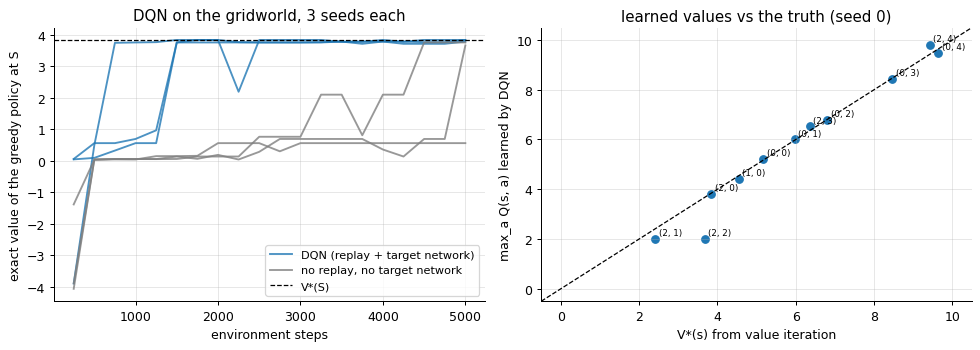

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for (cfg, runs), col in zip(dq.items(), ("tab:blue", "tab:gray")):
    x = np.arange(1, len(runs[0][0]) + 1) * 250
    for k, (c, _) in enumerate(runs):
        axes[0].plot(x, c, color=col, alpha=0.8, label=cfg if k == 0 else None)
axes[0].axhline(V_star[START], color="k", ls="--", lw=1, label="V*(S)")
axes[0].set_xlabel("environment steps"); axes[0].set_ylabel("exact value of the greedy policy at S")
axes[0].set_title("DQN on the gridworld, 3 seeds each"); axes[0].legend(fontsize=9)
Qn = dq["DQN (replay + target network)"][0][1]
axes[1].scatter(V_star[dec], Qn.max(1)[dec], color="tab:blue")
for s in np.flatnonzero(dec):
    axes[1].annotate(str(CELLS[s]), (V_star[s], Qn.max(1)[s]), fontsize=7, xytext=(3, 3), textcoords="offset points")
lim = [min(0, Qn.max(1)[dec].min()) - 0.5, 10.5]
axes[1].plot(lim, lim, "k--", lw=1); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("V*(s) from value iteration"); axes[1].set_ylabel("max_a Q(s, a) learned by DQN"); axes[1].set_title("learned values vs the truth (seed 0)")
plt.tight_layout(); plt.show()

**What just happened?** With replay and a target network the greedy policy reaches a value at S of 3.780, 3.832 and 3.832 in the 3 seeds, against $V^*(S) = 3.832$: two seeds find an optimal policy (agreeing with $\pi^*$ in every state), the third a nearly optimal one. The naive version is fragile: one seed is stuck at 0.556, the other two reach 3.655 and 3.752. The learned values (right) lie on the diagonal for 9 of the 11 decision cells. The two cells off it, (2, 1) and (2, 2) on the row next to the cliff, are the ones the safe policy avoids, so the agent rarely sees them once ε is small: a DQN only learns where it has data.

## 10. RLHF in miniature: preferences, a reward model and a KL leash

**RLHF** (reinforcement learning from human feedback) is how chat models are tuned after pre-training (InstructGPT, 2022). Three stages: (1) supervised fine-tuning gives a reference policy $\pi_{\text{ref}}$; (2) people compare pairs of answers and a **reward model** $\hat r$ is fitted to their choices; (3) the policy is optimised with RL (PPO) to maximise $\hat r$, with a penalty for moving away from $\pi_{\text{ref}}$:
$$
\max_\pi\ \mathbb E_{y \sim \pi}[\hat r(y)] - \beta\, \mathrm{KL}(\pi \,\|\, \pi_{\text{ref}}).
$$

We replace the language model by a toy: one prompt, 1,000 possible answers, each with a quality and a length $\ell$ (standardised, 0 = typical). The labellers' real preference is a utility $u = \text{quality} + 0.6\,\ell - 0.3\,\ell^2$: some extra length helps, too much hurts. The reference policy rarely writes long answers, $\pi_{\text{ref}}(y) \propto e^{-\ell^2/2}$, so the labellers only ever compare answers of ordinary length.

**Bradley–Terry model.** A labeller prefers answer $y_1$ to $y_2$ with probability $\sigma\big(\hat r(y_1) - \hat r(y_2)\big)$. Fitting it by maximum likelihood, $\max \sum_{\text{pairs}} \log \sigma\big(\hat r(y_w) - \hat r(y_l)\big)$ with $y_w$ the preferred answer, is a logistic regression on feature differences. Our reward model is linear in (quality, length).

In [23]:
rng = np.random.default_rng(0)
n_resp = 1000
quality = rng.normal(size=n_resp)                     # how good the answer is
length = rng.uniform(-3, 5, size=n_resp)              # standardised length (0 = typical)
utility = quality + 0.6 * length - 0.3 * length ** 2  # what the labellers really prefer: some length helps, too much hurts
pi_ref = np.exp(-length ** 2 / 2); pi_ref /= pi_ref.sum()   # the reference (SFT) model rarely writes very long answers

n_pairs = 2000                                        # labellers compare two answers sampled from π_ref
i, j = rng.choice(n_resp, n_pairs, p=pi_ref), rng.choice(n_resp, n_pairs, p=pi_ref)
prefer_i = rng.random(n_pairs) < 1 / (1 + np.exp(-(utility[i] - utility[j])))   # Bradley–Terry choice
feats = np.stack([quality, length], 1)                # the reward model is linear: r̂ = w_q·quality + w_ℓ·length
D, y = feats[i] - feats[j], prefer_i.astype(float)
train, test = np.arange(1500), np.arange(1500, 2000)

w = np.zeros(2)                                       # Bradley–Terry = logistic regression on feature differences
for _ in range(3000):
    p = 1 / (1 + np.exp(-D[train] @ w))
    w -= 1.0 * D[train].T @ (p - y[train]) / len(train)
from sklearn.linear_model import LogisticRegression
w_sk = LogisticRegression(fit_intercept=False, C=1e6).fit(D[train], y[train]).coef_[0]
acc = np.mean((D[test] @ w > 0) == prefer_i[test])
print(f"reward model from scratch: w = {w.round(3)}   scikit-learn: {w_sk.round(3)}")
print(f"held-out pairs predicted correctly: {100 * acc:.1f} %   lengths seen by the labellers (1st–99th percentile): {np.percentile(length[np.r_[i, j]], [1, 99]).round(2)}")
assert np.allclose(w, w_sk, atol=1e-3)
r_hat = feats @ w

reward model from scratch: w = [0.905 0.447]   scikit-learn: [0.905 0.447]
held-out pairs predicted correctly: 71.2 %   lengths seen by the labellers (1st–99th percentile): [-2.21  2.29]


The Bradley–Terry fit from scratch and scikit-learn's logistic regression agree: $\hat r = 0.905 \cdot \text{quality} + 0.447 \cdot \ell$. It predicts 71.2 % of the held-out choices (the choices are random by design, so 100 % is impossible). And it learned that length helps, which is true for the lengths the labellers saw, from −2.2 to 2.3.

**The KL-regularised optimum in closed form.** For a finite set of answers,
$$
\mathbb E_\pi[\hat r] - \beta\, \mathrm{KL}(\pi \,\|\, \pi_{\text{ref}}) = -\beta\, \mathrm{KL}(\pi \,\|\, \pi^*_\beta) + \beta \log Z,
\qquad \pi^*_\beta(y) = \frac{\pi_{\text{ref}}(y)\, e^{\hat r(y)/\beta}}{Z}.
$$
(Expand the right-hand side with $\log \pi^*_\beta = \log \pi_{\text{ref}} + \hat r/\beta - \log Z$.) The KL divergence is $\ge 0$ and zero only when $\pi = \pi^*_\beta$, so $\pi^*_\beta$ is the maximiser. Large $\beta$: stay close to the reference. $\beta \to 0$: put everything on the answer with the highest $\hat r$. PPO in real RLHF approximates this optimum with sampled answers, for a model that cannot enumerate them. **DPO** (Rafailov et al., 2023) inverts the formula, $\hat r = \beta \log(\pi / \pi_{\text{ref}}) + \text{const}$, and fits the policy directly to the preferences with the Bradley–Terry loss: no reward model, no RL.

In [24]:
def kl_optimal(beta):
    """argmax_π E_π[r̂] − β KL(π || π_ref) = π_ref · exp(r̂ / β) / Z."""
    logits = np.log(pi_ref) + r_hat / beta
    p = np.exp(logits - logits.max())
    return p / p.sum()

# check the closed form against gradient ascent on free logits for β = 0.5
beta = 0.5
z = torch.zeros(n_resp, requires_grad=True); opt = torch.optim.Adam([z], lr=0.05)
lr_ref, rt = torch.as_tensor(np.log(pi_ref)), torch.as_tensor(r_hat)
for _ in range(3000):
    p = torch.softmax(z.double(), 0)
    objective = (p * rt).sum() - beta * (p * (torch.log(p) - lr_ref)).sum()
    opt.zero_grad(); (-objective).backward(); opt.step()
gap = np.abs(torch.softmax(z.double(), 0).detach().numpy() - kl_optimal(beta)).max()
print(f"β = 0.5: max |gradient ascent − closed form| = {gap:.1e}")
assert gap < 1e-3

betas = np.array([10, 5, 3, 2, 1.5, 1, 0.7, 0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.12, 0.1, 0.08, 0.06, 0.05, 0.03, 0.02, 0.01])
rows = []
for b in betas:
    p = kl_optimal(b)
    rows.append((b, np.sum(p * (np.log(p + 1e-300) - np.log(pi_ref))), p @ r_hat, p @ utility, p @ length))
rows = np.array(rows)
print("   β     KL   proxy r̂   true utility   mean length")
for b, kl, pr, tr, ln in rows[[0, 5, 7, 9, 11, 14, 17, 20]]:
    print(f"{b:5.2f} {kl:6.2f} {pr:9.3f} {tr:12.3f} {ln:12.2f}")
k_best = rows[:, 3].argmax()
print(f"best true utility {rows[k_best, 3]:.3f} at β = {rows[k_best, 0]} (KL {rows[k_best, 1]:.2f});"
      f" reference policy: {pi_ref @ utility:.3f};  best single answer: {utility.max():.3f}")

β = 0.5: max |gradient ascent − closed form| = 1.1e-06
   β     KL   proxy r̂   true utility   mean length
10.00   0.00    -0.028       -0.317        -0.02
 1.00   0.45     0.792        0.573         0.36
 0.50   1.85     1.715        1.375         0.90
 0.30   5.66     3.159        2.324         1.96
 0.20   7.81     3.713        2.687         2.32
 0.10  11.04     4.110        1.214         3.28
 0.05  17.26     4.635       -1.269         4.80
 0.01  17.27     4.635       -1.271         4.80
best true utility 2.687 at β = 0.2 (KL 7.81); reference policy: -0.426;  best single answer: 2.883


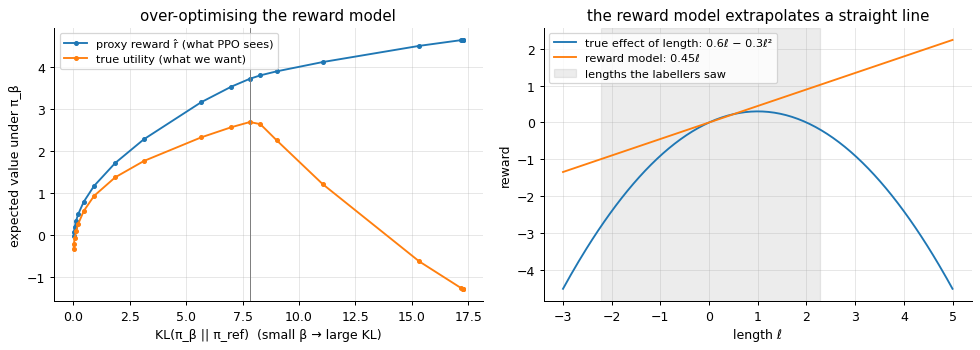

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rows[:, 1], rows[:, 2], "-o", ms=3, label="proxy reward r̂ (what PPO sees)")
axes[0].plot(rows[:, 1], rows[:, 3], "-o", ms=3, label="true utility (what we want)")
axes[0].axvline(rows[k_best, 1], color="gray", lw=0.8)
axes[0].set_xlabel("KL(π_β || π_ref)  (small β → large KL)"); axes[0].set_ylabel("expected value under π_β")
axes[0].set_title("over-optimising the reward model"); axes[0].legend(fontsize=9)
ell = np.linspace(-3, 5, 200)
axes[1].plot(ell, 0.6 * ell - 0.3 * ell ** 2, label="true effect of length: 0.6ℓ − 0.3ℓ²")
axes[1].plot(ell, w[1] * ell, label=f"reward model: {w[1]:.2f}ℓ")
lo, hi = np.percentile(length[np.r_[i, j]], [1, 99])
axes[1].axvspan(lo, hi, color="gray", alpha=0.15, label="lengths the labellers saw")
axes[1].set_xlabel("length ℓ"); axes[1].set_ylabel("reward"); axes[1].legend(fontsize=9)
axes[1].set_title("the reward model extrapolates a straight line")
plt.tight_layout(); plt.show()

**What just happened?** Gradient ascent on free logits converges to the closed form (difference $10^{-6}$). As $\beta$ decreases the policy moves away from $\pi_{\text{ref}}$ (the KL grows) and the proxy reward rises steadily, from −0.03 to 4.64. The true utility rises with it at first, from −0.32 to 2.69 at $\beta = 0.2$ (KL 7.8), then collapses to −1.27 as $\beta \to 0$, worse than the reference policy (−0.43). The optimised policy writes answers of length 4.8, far outside anything the labellers saw, where the reward model's straight line says "even better" and the truth says "much worse".

This is **reward hacking**, or over-optimisation (Gao et al., 2022): the policy finds the reward model's mistakes. The KL penalty is the leash. With a well-chosen $\beta$ (here 0.2) RL raises the true utility from −0.43 to 2.69, close to the best single answer, 2.88. Real systems also refresh the reward model with comparisons of the new policy's answers, which is the real fix: data where the policy now goes.

In [26]:
print(f"whole notebook: {(time.time() - T_START) / 60:.1f} min on {device}")

whole notebook: 1.3 min on cpu


## 11. Summary

- **The setting.** An agent observes $S_t$, acts $A_t$, receives $R_{t+1}$ and $S_{t+1}$; it maximises the expected return $G_t = \sum_k \gamma^k R_{t+k+1} = R_{t+1} + \gamma G_{t+1}$. No labels, delayed rewards, and the agent's actions decide its data.
- **Bandits** (one state): regret $\sum_t (\mu^* - \mu_{A_t})$. Greedy gets stuck (38 % of runs, regret 297 at $T = 5000$); ε-greedy has linear regret (slope $\varepsilon(\mu^* - \bar\mu) = 0.033$, regret 214); UCB $\hat\mu_a + c\sqrt{\ln t/N_a}$ and Thompson sampling (Beta posteriors) have logarithmic regret (UCB with $c = 0.5$: 60, Thompson: 62; UCB1 with $c = \sqrt2$: 323 at this horizon).
- **Bellman expectation**: $V^\pi(s) = \sum_a \pi(a|s)\sum_{s'}P(s'|s,a)\,[r + \gamma V^\pi(s')]$, a linear system $V^\pi = (\mathbf I - \gamma P_\pi)^{-1} r_\pi$. Random policy on the gridworld: $V(S) = -5.911$ (Monte Carlo: $-5.85 \pm 0.06$).
- **Bellman optimality**: $V^*(s) = \max_a \sum_{s'}P(s'|s,a)\,[r + \gamma V^*(s')]$; $\pi^* = \arg\max_a Q^*$. Value iteration is a γ-contraction, $\|V_k - V^*\| \le \gamma^k\|V_0 - V^*\|$ (80 sweeps; the greedy policy is optimal from sweep 8). Policy iteration: 4 improvements. Both give $V^*(S) = 3.832$ and the same safe 7-move route.
- **γ, noise and rewards** change the optimal policy: +1 near vs +10 far switches at $\gamma = 1/\sqrt{10}$; slip 0.2 moves the path away from the cliff; a reward of +1 per move makes the agent never leave, −2 per move makes it rush along the cliff.
- **TD(0)**: $V(S_t) \leftarrow V(S_t) + \alpha[R_{t+1} + \gamma V(S_{t+1}) - V(S_t)]$; biased, low variance, online. On the random walk, RMS error after 25 episodes: TD 0.057, MC 0.140.
- **SARSA** (on-policy, target $Q(S', A')$) vs **Q-learning** (off-policy, target $\max_{a'} Q(S', a')$): on the cliff, SARSA walks the safe path (online return −29.2), Q-learning the optimal edge (13 moves, online return −49.7 while exploring).
- **REINFORCE**: $\nabla_\theta J = \mathbb E[\sum_t G_t \nabla_\theta \log \pi_\theta(A_t|S_t)]$ by the log-derivative trick; a baseline keeps it unbiased and cuts the variance (÷ 1.8 on the toy bandit). CartPole: last-100-episode length 491 with a learned baseline vs 433 without.
- **DQN**: squared TD error with a target network and experience replay; on the gridworld it finds $V(S) = 3.78$–$3.83$ (optimum 3.832), the naive version gets stuck in one seed of three.
- **RLHF**: Bradley–Terry reward model ($\sigma(\hat r_w - \hat r_l)$, 71 % held-out accuracy), then $\max_\pi \mathbb E[\hat r] - \beta\,\mathrm{KL}(\pi\|\pi_{\text{ref}})$, optimum $\pi_{\text{ref}}\,e^{\hat r/\beta}/Z$. Too small a β over-optimises the proxy: true utility 2.69 at β = 0.2, −1.27 as β → 0.

## Exercises

Try each one before opening the answer.

1. **Bellman by hand.** Check that $V = (1/6, 2/6, 3/6, 4/6, 5/6)$ satisfies the Bellman expectation equation of the random walk of section 6. Why is it the only solution?
2. **A step cost.** In the gridworld with slip 0, give every ordinary move a reward of −0.1 instead of 0. For which γ does the agent at S now prefer the +10 exit? Set up the inequality and solve it.
3. **ε-greedy.** Show that the regret of ε-greedy grows at least like $\varepsilon\,(\mu^* - \bar\mu)\,T$, with $\bar\mu$ the mean of all arms. Propose a schedule $\varepsilon_t$ that avoids linear regret.
4. **Contraction.** Show that the policy-evaluation map $\mathcal T_\pi V = r_\pi + \gamma P_\pi V$ is a γ-contraction in the max norm. What can go wrong with $\gamma = 1$, and why is the random walk of section 6 still fine?
5. **SARSA with less exploration.** In cliff walking, what path does SARSA learn if ε decreases to 0 during training? And Q-learning?
6. **Baselines.** Prove that a baseline $b(s)$ does not bias the policy gradient. Why would a "baseline" $b(s, a)$ that depends on the action introduce bias in general?
7. **Reward hacking.** In section 10, propose two ways to reduce over-optimisation other than increasing β, and say what each one changes in the experiment.

<details>
<summary><b>Answers</b></summary>

**1.** With $\gamma = 1$ and reward 0 except when leaving on the right, the equation is $V(s) = \tfrac12 V(s-1) + \tfrac12 V(s+1)$ for the inner states, with $V(\text{left end}) = 0$ and $V(\text{right end}) = 1$ (the reward 1 plays the role of the right end's value). For $V(s) = s/6$ with $s = 1, \dots, 5$: $\tfrac12\,\tfrac{s-1}{6} + \tfrac12\,\tfrac{s+1}{6} = \tfrac{s}{6}$. At A: $\tfrac12 \cdot 0 + \tfrac12 \cdot \tfrac26 = \tfrac16$; at E: $\tfrac12 \cdot \tfrac46 + \tfrac12 \cdot 1 = \tfrac56$. The solution is unique because the system is $V = r_\pi + P_\pi V$ restricted to the inner states, and the walk leaves them with probability 1, so $\mathbf I - P_\pi$ (inner part) is invertible: $P_\pi^k \to 0$.

**2.** Near exit (3 moves, the 3rd enters A): $G = -0.1 - 0.1\gamma + \gamma^2$. Far exit (5 moves): $G = -0.1(1 + \gamma + \gamma^2 + \gamma^3) + 10\gamma^4$. Far minus near $= \gamma^2(10\gamma^2 - 0.1\gamma - 1.1)$, positive when $10\gamma^2 - 0.1\gamma - 1.1 > 0$, that is $\gamma > (0.1 + \sqrt{0.01 + 44})/20 = 0.337$. The step cost makes long paths more expensive, so the switch moves up from 0.316. You can check it with `make_mdp(0.0, -0.1)` and the sweep of section 5.

**3.** At every step, with probability $\varepsilon$ the arm is uniform, so the expected regret of that step is at least $\varepsilon \cdot \frac1K\sum_a \Delta_a = \varepsilon(\mu^* - \bar\mu)$, whatever the estimates. Summed over $T$ steps: at least $\varepsilon(\mu^* - \bar\mu)T$, linear in $T$ (0.033 per step here). A decreasing schedule, $\varepsilon_t = \min(1, cK/(d^2 t))$ with $d$ a lower bound on the gap, gives logarithmic regret (Auer et al., 2002); in practice $\varepsilon_t \propto 1/t$ or Thompson sampling.

**4.** $\|\mathcal T_\pi V - \mathcal T_\pi U\|_\infty = \gamma\,\|P_\pi(V - U)\|_\infty \le \gamma\,\|V - U\|_\infty$, because each row of $P_\pi$ is non-negative and sums to 1, so $|(P_\pi x)_s| \le \max_{s'}|x_{s'}|$. With $\gamma = 1$ the factor is 1 and the argument fails: in a task that can last forever (for example the +1 per move gridworld) the return can be infinite. In an episodic task where every policy ends with probability 1, like the random walk, $P_\pi$ restricted to the non-terminal states has spectral radius below 1, so the values exist and the iteration still converges.

**5.** With ε → 0 the exploratory falls disappear from SARSA's targets, so SARSA's values converge to those of the greedy policy and it ends on the optimal path along the edge, like Q-learning (this needs ε to decrease slowly enough for every state–action pair to be tried infinitely often, the "GLIE" condition). Q-learning already learns the optimal values; with less exploration it also falls less, so its online return improves to −13.

**6.** $\mathbb E_{a\sim\pi}[b(s)\nabla_\theta\log\pi_\theta(a|s)] = b(s)\sum_a\pi_\theta(a|s)\frac{\nabla_\theta\pi_\theta(a|s)}{\pi_\theta(a|s)} = b(s)\nabla_\theta\sum_a\pi_\theta(a|s) = b(s)\nabla_\theta 1 = 0$, for every state, so subtracting it changes the variance but not the mean. With $b(s, a)$ the factor cannot be taken out of the sum: $\sum_a b(s,a)\nabla_\theta\pi_\theta(a|s)$ is not zero in general, so the estimate is biased (this is why actor–critic methods use $V(s)$, or correct for action-dependent baselines explicitly).

**7.** (a) **Collect comparisons where the policy goes**: label pairs sampled from the optimised policy, not only from $\pi_{\text{ref}}$, and refit $\hat r$; in the experiment, pairs with long answers would teach the model that length beyond about 1 hurts. (b) **A better reward model**: add $\ell^2$ as a feature (here it would recover the true utility), or use an ensemble of reward models and optimise a pessimistic estimate (mean minus standard deviation), which penalises regions with little data. Also: early stopping of the RL step, monitoring true quality on a held-out human evaluation, and length penalties when length is a known exploit.

</details>